# 世界GDPの国別分布と地域差

run_id: `v020-exp-30`。計画・コード・出力・根拠付きInsightを保存する。APIトークンは表示しない。実行はJupyter MCPのみ。Notebook本文の作成・更新は `project_manager.enqueue_write` を使用し、セル実行と実出力の保存はJupyter MCPに委ねる。

## 分析計画（取得前）
1. Kaggle SDKで認証・検索・ファイル一覧・取得を試行し、取得物のSHA-256と日時を記録する。失敗時のみ指定の旧実験CSVへ切り替える。
2. 国・地域の識別、年・GDPの単位・名目/実質/PPPの確からしさをmanifestで区別する。欠損・重複・負値・ゼロ・国コードと地域対応を点検する。
3. 線形/対数分布、平均対中央値、歪度、上位国シェア、Lorenz曲線/Giniで偏りを確認する。大国を外れ値として自動削除しない。
4. 地域別に合計・国数・中央値・四分位範囲を併記し、経済規模と典型的な国を分ける。地域別対数箱ひげと全GDPシェアを図示する。
5. 初回結果を読んで結論に影響する追加依頼を最大3回行う。大国除外、地域区分、閾値・欠損への感度を測る。
6. 全コードセルを上から再実行し、`audit_notebook(visual_audit=True)` とlifecycleの静止・completedを確認する。

## GDPの解釈の基本注意
総GDPは人口規模を含む経済規模であり、一人当たり所得・生活水準・分配・幸福度ではない。ドル換算額は為替の影響を受ける。PPP・実質GDP・異なる年のGDPと直接比較しない。単年の地域差から政策や地理の因果効果を主張しない。データ収録対象の合計は公式な世界GDPとは限らない。


In [1]:
# 01 環境・実行登録
from pathlib import Path
import os, sys, json, io, hashlib, contextlib, traceback
from datetime import datetime, timezone
from dataclasses import asdict
ROOT = Path('/home/nahisaho/GitHub/jupytermind')
sys.path.insert(0, str(ROOT / 'src'))
os.environ['AI_DATA_SCIENTIST_PROJECTS_ROOT'] = str(ROOT / 'benchmark/projects')
import nbformat, pandas as pd, numpy as np, requests
from IPython.display import display, Markdown
from ai_data_scientist import project_manager as pm, lifecycle, language_router
RUN_ID = 'v020-exp-30'
handle = pm.resolve_project('kaggle-v020-kaggle-exp-30-world-gdp')
lifecycle.register_run(RUN_ID, handle.notebook_path)
pm.ensure_notebook(handle)
data_dir = pm.ensure_data_dir(handle)
lang = language_router.detect_language('国ごとのGDP分布と地域差を日本語で分析してください')
def now_utc():
    return datetime.now(timezone.utc).isoformat()
def log_lifecycle(event):
    rec = {'event':event,'utc':now_utc(),**asdict(lifecycle.get_run_status(RUN_ID))}
    with (data_dir/'lifecycle_events.jsonl').open('a',encoding='utf-8') as log:
        log.write(json.dumps(rec,ensure_ascii=False)+'\n')
    print(json.dumps(rec,ensure_ascii=False))
def phase(name, fn):
    if lifecycle.is_cancel_requested(RUN_ID):
        raise RuntimeError('実行中止が要求されています')
    lifecycle.mark_execution_start(RUN_ID)
    log_lifecycle(name+':execution_start')
    try:
        return fn()
    except Exception:
        lifecycle.mark_failed(RUN_ID)
        raise
    finally:
        lifecycle.mark_execution_end(RUN_ID)
        log_lifecycle(name+':execution_end')
def write_notebook(mutation):
    lifecycle.mark_write_start(RUN_ID)
    log_lifecycle('notebook_write_start')
    try:
        return pm.enqueue_write(handle, mutation)
    finally:
        lifecycle.mark_write_end(RUN_ID)
        log_lifecycle('notebook_write_end')
log_lifecycle('register_run')
print('言語:', lang, 'run_id:', RUN_ID)
print('保存先:', handle.notebook_path)
print(asdict(lifecycle.get_run_status(RUN_ID)))


{"event": "register_run", "utc": "2026-10-01T21:29:11.321343+00:00", "run_id": "v020-exp-30", "state": "running", "active_cell_executions": 0, "pending_notebook_writes": 0, "locks_held": 0, "notebook_path": "/home/nahisaho/GitHub/jupytermind/benchmark/projects/kaggle-v020-kaggle-exp-30-world-gdp/notebooks/kaggle-v020-kaggle-exp-30-world-gdp.ipynb", "reason": null}
言語: ja run_id: v020-exp-30
保存先: /home/nahisaho/GitHub/jupytermind/benchmark/projects/kaggle-v020-kaggle-exp-30-world-gdp/notebooks/kaggle-v020-kaggle-exp-30-world-gdp.ipynb
{'run_id': 'v020-exp-30', 'state': 'running', 'active_cell_executions': 0, 'pending_notebook_writes': 0, 'locks_held': 0, 'notebook_path': '/home/nahisaho/GitHub/jupytermind/benchmark/projects/kaggle-v020-kaggle-exp-30-world-gdp/notebooks/kaggle-v020-kaggle-exp-30-world-gdp.ipynb', 'reason': None}


In [2]:
# 02 Kaggle API検索・ファイル取得（秘密情報を出力しない）
def acquire_gdp():
    global provenance, raw_path, kaggle_search_log, KaggleApi
    kaggle_search_log = []
    failure = None
    chosen = None
    try:
        # SDK import時の自動認証メッセージもNotebookに出さない。
        with contextlib.redirect_stdout(io.StringIO()), contextlib.redirect_stderr(io.StringIO()):
            from kaggle.api.kaggle_api_extended import KaggleApi
            api = KaggleApi()
            api.authenticate()
        for query in ['world gdp by country', '2014 world gdp', 'gdp countries']:
            with contextlib.redirect_stdout(io.StringIO()), contextlib.redirect_stderr(io.StringIO()):
                candidates = api.dataset_list(search=query, page=1)[:10]
            refs = [str(d.ref) for d in candidates]
            kaggle_search_log.append({'search': query, 'refs': refs})
            for d in candidates:
                ref = str(d.ref)
                with contextlib.redirect_stdout(io.StringIO()), contextlib.redirect_stderr(io.StringIO()):
                    listing = api.dataset_list_files(ref)
                files = getattr(listing, 'files', [])
                file_names = [str(f.name) for f in files]
                kaggle_search_log.append({'ref': ref, 'files': file_names})
                exact = [n for n in file_names if '2014_world_gdp' in n.lower() and n.lower().endswith('.csv')]
                if exact:
                    chosen = (ref, exact[0], str(getattr(d, 'title', '')))
                    break
            if chosen:
                break
        if chosen is None:
            failure = {'stage': 'search_files', 'type': 'NoCompatibleFile', 'message': '3検索・各最大10候補で2014_world_gdp CSVに対応するファイルが見つからなかった。年・単位不明の別データを同一と扱わない。'}
        else:
            ref, filename, title = chosen
            with contextlib.redirect_stdout(io.StringIO()), contextlib.redirect_stderr(io.StringIO()):
                api.dataset_download_file(ref, filename, path=str(data_dir), force=True, quiet=True)
            raw_path = data_dir / filename
            if not raw_path.exists():
                import zipfile
                zipped = data_dir / (Path(filename).name + '.zip')
                if not zipped.exists():
                    raise FileNotFoundError('取得ファイルが存在しない')
                with zipfile.ZipFile(zipped) as archive:
                    names = archive.namelist()
                    member = next(n for n in names if Path(n).name == Path(filename).name)
                    raw_path = data_dir / Path(filename).name
                    raw_path.write_bytes(archive.read(member))
            provenance = {'route': 'Kaggle API', 'owner_dataset_slug': ref, 'file': filename, 'title': title, 'retrieved_at_utc': now_utc(), 'sha256': hashlib.sha256(raw_path.read_bytes()).hexdigest(), 'search_log': kaggle_search_log}
    except (Exception, SystemExit) as exc:
        # 認証例外の本文・HTTPヘッダ・環境変数は一切表示しない。
        failure = {'stage': 'Kaggle authenticate/search/download', 'type': type(exc).__name__, 'message': 'Kaggle API認証または検索・取得に失敗。秘密を含み得る例外本文は保存しない。', 'safe_trace': [{'function': f.name, 'file': Path(f.filename).name, 'line': f.lineno} for f in traceback.extract_tb(exc.__traceback__)], 'status_code': getattr(getattr(exc, 'response', None), 'status_code', None)}
    if failure is not None:
        legacy = Path('/home/nahisaho/kaggle/experiments/white-paper.md')
        url = 'https://raw.githubusercontent.com/plotly/datasets/master/2014_world_gdp_with_codes.csv'
        legacy_verified = legacy.exists() and url in legacy.read_text(encoding='utf-8')
        response = requests.get(url, timeout=40)
        response.raise_for_status()
        raw_path = data_dir / '2014_world_gdp_with_codes.csv'
        raw_path.write_bytes(response.content)
        provenance = {'route': '指定公開CSVフォールバック', 'owner_dataset_slug': None, 'file': raw_path.name, 'url': url, 'retrieved_at_utc': now_utc(), 'sha256': hashlib.sha256(response.content).hexdigest(), 'kaggle_failure': failure, 'search_log': kaggle_search_log, 'legacy_document_url_confirmed': legacy_verified, 'reason': 'Kaggle APIで対応データを取得できなかったため。公開CSVとKaggle掲載版の完全な同一性は保証されない。'}
    (data_dir / 'provenance.json').write_text(json.dumps(provenance, ensure_ascii=False, indent=2), encoding='utf-8')
    display(Markdown('### データ取得記録'))
    print(json.dumps(provenance, ensure_ascii=False, indent=2))
    print(pd.read_csv(raw_path).head().to_string(index=False))
phase('Kaggle_API_取得', acquire_gdp)


{"event": "Kaggle_API_取得:execution_start", "utc": "2026-10-01T21:29:25.805712+00:00", "run_id": "v020-exp-30", "state": "running", "active_cell_executions": 1, "pending_notebook_writes": 0, "locks_held": 0, "notebook_path": "/home/nahisaho/GitHub/jupytermind/benchmark/projects/kaggle-v020-kaggle-exp-30-world-gdp/notebooks/kaggle-v020-kaggle-exp-30-world-gdp.ipynb", "reason": null}
{
  "route": "Kaggle API",
  "owner_dataset_slug": "wsaqaf/2014_world_gdp_with_codes.csv",
  "file": "2014_world_gdp_with_codes.csv",
  "title": "2014 world GDP data with country codes",
  "retrieved_at_utc": "2026-10-01T21:29:22.205577+00:00",
  "sha256": "e85b1a32bc551b225844dcb12b531bb2d60d366d121327fb743031314db6d4e1",
  "search_log": [
    {
      "search": "world gdp by country",
      "refs": [
        "willianoliveiragibin/world-gdp-by-country-region-and-income-group",
        "sazidthe1/world-gdp-data",
        "russellyates88/suicide-rates-overview-1985-to-2016",
        "fernandol/countries-of-the-

### データ取得記録

## データ定義と前提の確認
2014年ラベルのスナップショットを採用する。国・地域を含むので、国という略称は主権国家のみを意味しない。収録対象内の合計・シェアを用い、公式世界GDPとは表現しない。

原票でBritish Virgin IslandsとVirgin Islandsに同じVGBコードが付いていた。GDPはそのまま保持し、後者をVIRに推定補正する。削除はせず原コードを保持する。両者は米州なので大地域集計に影響しない。外部検証ではこの補正の妥当性も確認する。

In [3]:
# 03 読込み・品質点検・地域分類
from ai_data_scientist import ingestion, cleaning, eda, data_quality

def emit(label, value):
    display({'text/plain': label + '\n' + json.dumps(value, ensure_ascii=False, indent=2, default=str)}, raw=True)

def load_and_check():
    global df, eda_report, region_provenance, dataset_metadata
    ingested = ingestion.ingest(ingestion.SourceSpec('csv', str(raw_path)), row_limit=10000)
    raw = ingested.dataframe
    assert set(raw.columns) == {'COUNTRY', 'GDP (BILLIONS)', 'CODE'}, '想定と異なる列定義'
    clean = cleaning.clean_dataset(raw, operation='drop_duplicates')
    df = clean.dataframe.rename(columns={'COUNTRY':'country', 'GDP (BILLIONS)':'gdp', 'CODE':'code'}).copy()
    df['gdp'] = pd.to_numeric(df['gdp'], errors='raise')
    df['country'] = df['country'].str.strip()
    df['code'] = df['code'].str.strip()
    emit('読込み・整形', {'rows':len(df), 'columns':list(df.columns), 'truncated':ingested.truncated, 'rows_removed':clean.rows_removed, 'columns_affected':clean.columns_affected})
    eda_report = eda.explore(df)
    emit('EDA', asdict(eda_report))
    anomalies = data_quality.detect_anomalies(df, {'country':{'not_null':True,'unique':True}, 'code':{'not_null':True,'unique':True}, 'gdp':{'not_null':True,'min':0,'max':1e6}})
    emit('GDP意味的異常検査', {'anomalies':[asdict(x) for x in anomalies], 'nonfinite':int((~np.isfinite(df.gdp)).sum()), 'zero_gdp':df.loc[df.gdp.eq(0), ['country','code']].to_dict('records'), 'invalid_code':df.loc[~df.code.str.fullmatch('[A-Z]{3}'), 'code'].tolist()})
    emit('原票の重複コード詳細', df.loc[df.code.duplicated(keep=False)].to_dict('records'))
    df['code_raw'] = df.code
    corrections = {'Virgin Islands':'VIR','Bahamas, The':'BHS'}
    df.loc[df.country.eq('Bahamas, The'), 'code'] = 'BHS'
    df.loc[df.country.eq('Virgin Islands'), 'code'] = 'VIR'
    emit('明示的コード補正（推定）', {'rule':corrections,'reason':'British Virgin IslandsはVGBで別に存在するため、Virgin IslandsをUS Virgin Islands/VIRと推定。GDP値は変更しない。両者とも米州。'})
    post = data_quality.detect_anomalies(df, {'country':{'not_null':True,'unique':True},'code':{'not_null':True,'unique':True},'gdp':{'not_null':True,'min':0,'max':1e6}})
    emit('補正後検査', [asdict(x) for x in post])
    assert not post and np.isfinite(df.gdp).all()
    url = 'https://raw.githubusercontent.com/lukes/ISO-3166-Countries-with-Regional-Codes/master/all/all.csv'
    response = requests.get(url, timeout=40)
    response.raise_for_status()
    mapping_path = data_dir / 'iso3166_un_regions.csv'
    mapping_path.write_bytes(response.content)
    region_provenance = {'url':url,'retrieved_at_utc':now_utc(),'sha256':hashlib.sha256(response.content).hexdigest(),'note':'公開ISOコード・国連M49地域区分の転載。取得時点の区分であり2014年版とは限らない。'}
    mapping = pd.read_csv(mapping_path, dtype=str)
    assert mapping['alpha-3'].is_unique
    df = df.merge(mapping[['alpha-3','region','sub-region']], left_on='code', right_on='alpha-3', how='left', validate='one_to_one')
    # CSVのXKXはISO正式コードではない。分析者による明示的な暫定対応。
    region_overrides = {'KSV':('Europe','Southern Europe'), 'TWN':('Asia','Eastern Asia'), 'WBG':('Asia','Western Asia')}
    for code, values in region_overrides.items():
        df.loc[df.code.eq(code), ['region','sub-region']] = values
    emit('地域の明示的補完（推定）', region_overrides)
    unmapped = df.loc[df.region.isna(), ['country','code','gdp']]
    emit('地域対応', {'source':region_provenance, 'unmapped':unmapped.to_dict('records'), 'override_note':'Kosovo(KSV), Taiwan(TWN), West Bank(WBG)を国名と地理に基づき補完。West BankとPalestine全体は同一範囲と断定しない。'})
    assert unmapped.empty, '未対応地域を黙って除外しない'
    region_quality = data_quality.detect_anomalies(df, {'region':{'allowed':['Africa','Americas','Asia','Europe','Oceania'],'not_null':True}})
    emit('地域意味的異常検査', [asdict(x) for x in region_quality])
    assert not region_quality
    df.to_csv(data_dir / 'gdp_clean_regions.csv', index=False)
    print(df.groupby('region').size().to_string())
    dataset_metadata = {'title':provenance.get('title'), 'description':None, 'status':'未確認'}
    if provenance['route'] == 'Kaggle API':
        try:
            with contextlib.redirect_stdout(io.StringIO()), contextlib.redirect_stderr(io.StringIO()):
                meta_api = KaggleApi()
                meta_api.authenticate()
                meta_api.dataset_metadata(provenance['owner_dataset_slug'], path=str(data_dir))
                meta = json.loads((data_dir / 'dataset-metadata.json').read_text(encoding='utf-8'))
            meta_info = meta.get('info',meta)
            dataset_metadata = {k:meta_info.get(k) for k in ['title','subtitle','description','licenses']}
            dataset_metadata['scope_caveat'] = 'ライセンス名world-bankは原典・年・価格基準・全行の独立性の証明ではない。descriptionが空なら定義は未確認。'
            dataset_metadata['status'] = 'APIメタデータを確認'
        except Exception as exc:
            dataset_metadata['safe_error_type'] = type(exc).__name__
            dataset_metadata['status'] = 'メタデータ補助取得失敗。意味定義は未確認として扱う'
    emit('データ説明', dataset_metadata)
    (data_dir / 'region_provenance.json').write_text(json.dumps(region_provenance, ensure_ascii=False, indent=2), encoding='utf-8')
phase('読込み_地域対応_品質検査', load_and_check)


{"event": "読込み_地域対応_品質検査:execution_start", "utc": "2026-10-01T21:29:27.371316+00:00", "run_id": "v020-exp-30", "state": "running", "active_cell_executions": 1, "pending_notebook_writes": 0, "locks_held": 0, "notebook_path": "/home/nahisaho/GitHub/jupytermind/benchmark/projects/kaggle-v020-kaggle-exp-30-world-gdp/notebooks/kaggle-v020-kaggle-exp-30-world-gdp.ipynb", "reason": null}
region
Africa      54
Americas    48
Asia        51
Europe      49
Oceania     20
{"event": "読込み_地域対応_品質検査:execution_end", "utc": "2026-10-01T21:29:28.769534+00:00", "run_id": "v020-exp-30", "state": "running", "active_cell_executions": 0, "pending_notebook_writes": 0, "locks_held": 0, "notebook_path": "/home/nahisaho/GitHub/jupytermind/benchmark/projects/kaggle-v020-kaggle-exp-30-world-gdp/notebooks/kaggle-v020-kaggle-exp-30-world-gdp.ipynb", "reason": null}


読込み・整形
{
  "rows": 222,
  "columns": [
    "country",
    "gdp",
    "code"
  ],
  "truncated": false,
  "rows_removed": 0,
  "columns_affected": [
    "COUNTRY",
    "GDP (BILLIONS)",
    "CODE"
  ]
}

EDA
{
  "describe": {
    "gdp": {
      "count": 222.0,
      "mean": 352.6371621621622,
      "std": 1464.8555325721697,
      "min": 0.01,
      "25%": 4.615,
      "50%": 21.525,
      "75%": 196.2,
      "max": 17420.0
    }
  },
  "dtypes": {
    "country": "str",
    "gdp": "float64",
    "code": "str"
  },
  "non_null_counts": {
    "country": 222,
    "gdp": 222,
    "code": 222
  },
  "missing_summary": {
    "country": {
      "missing_count": 0,
      "missing_ratio": 0.0
    },
    "gdp": {
      "missing_count": 0,
      "missing_ratio": 0.0
    },
    "code": {
      "missing_count": 0,
      "missing_ratio": 0.0
    }
  },
  "categorical_summary": {
    "country": {
      "unique_count": 222,
      "top_values": [
        {
          "value": "Afghanistan",
          "count": 1,
          "ratio": 0.0045045045045045045
        },
        {
          "value": "Albania",
          "count": 1,
          "ratio": 0.0045045045045045045
        },
        {
          "value":

GDP意味的異常検査
{
  "anomalies": [
    {
      "column": "code",
      "rule": "unique",
      "row_count": 2,
      "message": "Column 'code' has 2 duplicate value(s).",
      "row_indices": [
        28,
        217
      ]
    }
  ],
  "nonfinite": 0,
  "zero_gdp": [],
  "invalid_code": []
}

原票の重複コード詳細
[
  {
    "country": "British Virgin Islands",
    "gdp": 1.1,
    "code": "VGB"
  },
  {
    "country": "Virgin Islands",
    "gdp": 5.08,
    "code": "VGB"
  }
]

...

補正後検査
[]

地域の明示的補完（推定）
{
  "KSV": [
    "Europe",
    "Southern Europe"
  ],
  "TWN": [
    "Asia",
    "Eastern Asia"
  ],
  "WBG": [
    "Asia",
    "Western Asia"
  ]
}

地域対応
{
  "source": {
    "url": "https://raw.githubusercontent.com/lukes/ISO-3166-Countries-with-Regional-Codes/master/all/all.csv",
    "retrieved_at_utc": "2026-10-01T21:29:27.617982+00:00",
    "sha256": "347bba35029f804f53780062052499781d267b8a5d887bf3b051e80a68390d6d",
    "note": "公開ISOコード・国連M49地域区分の転載。取得時点の区分であり2014年版とは限らない。"
  },
  "unmapped": [],
  "override_note": "Kosovo(KSV), Taiwan(TWN), West Bank(WBG)を国名と地理に基づき補完。West BankとPalestine全体は同一範囲と断定しない。"
}

地域意味的異常検査
[]

データ説明
{
  "title": "2014 world GDP data with country codes",
  "subtitle": "",
  "description": "",
  "licenses": [
    {
      "name": "world-bank"
    }
  ],
  "scope_caveat": "ライセンス名world-bankは原典・年・価格基準・全行の独立性の証明ではない。descriptionが空なら定義は未確認。",
  "status": "APIメタデータを確認"
}

In [4]:
# 04 データ定義manifest・分析前提manifest
from ai_data_scientist import data_definition, analysis_assumptions
FV = data_definition.FieldValue
manifest = data_definition.build_manifest(
    source={'file':FV(provenance['file'],'verified','取得記録'), 'sha256':FV(provenance['sha256'],'verified','取得バイト列'), 'publisher':FV(provenance.get('owner_dataset_slug'),'verified','Kaggle API'), 'upstream_method':FV(None,'unknown','原典・推計方法の十分な説明がない')},
    dataset_scope={'year':FV(2014,'verified','Kaggleタイトル・ファイル名'), 'entities':FV('収録された国・地域。主権国家のみではない','verified','COUNTRY一覧'), 'coverage_complete':FV(None,'unknown','全世界を完全にカバーする保証なし')},
    variables={'gdp':{'scale':FV('billions = 10^9','verified','GDP (BILLIONS)列名'), 'currency':FV('USD','inferred','規模・データのタイトルから推定、原典未確認'), 'price_basis':FV('名目・市場為替換算の総GDPに相当すると推定','inferred','値の水準。PPP/実質の一次定義未確認'), 'reference_year_per_row':FV(None,'unknown','行ごとの観測年列がない')}, 'region':{'definition':FV('国連M49大地域5区分。米州は一つ','verified','ISO3166公開対応表'), 'vintage':FV('取得時点、2014年版ではない可能性','inferred',region_provenance['url']), 'virgin_islands_code':FV('VGB→VIR、国名からの分析者推定','inferred','原票重複コード点検'), 'kosovo':FV('Europeへの分析者補完','inferred','原票KSVをEuropeへ補完。台湾はEastern Asia、West BankはWestern Asia。BHMはBHSへ補正')}},
    transformations=('完全重複のみ除去','GDPを数値化','ISO alpha-3で1対1地域結合','原票VGB重複のVirgin IslandsをVIR推定補正、BHMをBHS補正','KSV・TWN・WBGの地域を明示補完'))
emit('データ定義manifest', asdict(manifest))
emit('unknownフィールド', [(k,asdict(v)) for k,v in manifest.unresolved_fields()])
inferred = {**{k:asdict(v) for k,v in manifest.source.items() if v.status=='inferred'}, **{vname+'.'+k:asdict(v) for vname,fields in manifest.variables.items() for k,v in fields.items() if v.status=='inferred'}}
emit('inferredフィールド（unknownとは別に必ず報告）', inferred)
assumptions = analysis_assumptions.AnalysisAssumptionManifest(
    analysis_scope={'year_label':2014,'unit':'収録国・地域を各1観測','claim':'記述統計のみ','population_weighted':False},
    assumptions=(analysis_assumptions.Assumption('common-unit','各行GDPは同じ年・通貨・価格基準で比較可能','assumed',impact_if_false='国際比較・シェアの解釈が変わる',conclusion_critical=True), analysis_assumptions.Assumption('regions','取得時点のM49大地域を2014年データにも使う','assumed',impact_if_false='境界国の地域順位が変わる',conclusion_critical=True), analysis_assumptions.Assumption('no-trim','巨大GDPを測定異常として削除しない','tested',impact_if_false='集中度が過小になる'), analysis_assumptions.Assumption('observed-universe','収録対象内の差であり世界の全主権国家を代表すると断言しない','verified')),
    causal_scope='descriptive')
assumption_findings = analysis_assumptions.check_manifest(assumptions)
emit('分析前提manifest', asdict(assumptions))
emit('前提チェックの全finding', [asdict(x) for x in assumption_findings])
(data_dir / 'data_definition_manifest.json').write_text(json.dumps(asdict(manifest), ensure_ascii=False, indent=2), encoding='utf-8')
(data_dir / 'analysis_assumptions_manifest.json').write_text(json.dumps(asdict(assumptions), ensure_ascii=False, indent=2), encoding='utf-8')


データ定義manifest
{
  "source": {
    "file": {
      "value": "2014_world_gdp_with_codes.csv",
      "status": "verified",
      "source": "取得記録"
    },
    "sha256": {
      "value": "e85b1a32bc551b225844dcb12b531bb2d60d366d121327fb743031314db6d4e1",
      "status": "verified",
      "source": "取得バイト列"
    },
    "publisher": {
      "value": "wsaqaf/2014_world_gdp_with_codes.csv",
      "status": "verified",
      "source": "Kaggle API"
    },
    "upstream_method": {
      "value": null,
      "status": "unknown",
      "source": "原典・推計方法の十分な説明がない"
    }
  },
  "dataset_scope": {
    "year": {
      "value": 2014,
      "status": "verified",
      "source": "Kaggleタイトル・ファイル名"
    },
    "entities": {
      "value": "収録された国・地域。主権国家のみではない",
      "status": "verified",
      "source": "COUNTRY一覧"
    },
    "coverage_complete": {
      "value": null,
      "status": "unknown",
      "source": "全世界を完全にカバーする保証なし"
    }
  },
  "variables": {
    "gdp": {
      "scale": {
        "value": "bi

unknownフィールド
[
  [
    "source.upstream_method",
    {
      "value": null,
      "status": "unknown",
      "source": "原典・推計方法の十分な説明がない"
    }
  ],
  [
    "dataset_scope.coverage_complete",
    {
      "value": null,
      "status": "unknown",
      "source": "全世界を完全にカバーする保証なし"
    }
  ],
  [
    "variables.gdp.reference_year_per_row",
    {
      "value": null,
      "status": "unknown",
      "source": "行ごとの観測年列がない"
    }
  ]
]

inferredフィールド（unknownとは別に必ず報告）
{
  "gdp.currency": {
    "value": "USD",
    "status": "inferred",
    "source": "規模・データのタイトルから推定、原典未確認"
  },
  "gdp.price_basis": {
    "value": "名目・市場為替換算の総GDPに相当すると推定",
    "status": "inferred",
    "source": "値の水準。PPP/実質の一次定義未確認"
  },
  "region.vintage": {
    "value": "取得時点、2014年版ではない可能性",
    "status": "inferred",
    "source": "https://raw.githubusercontent.com/lukes/ISO-3166-Countries-with-Regional-Codes/master/all/all.csv"
  },
  "region.virgin_islands_code": {
    "value": "VGB→VIR、国名からの分析者推定",
    "status": "inferred",
    "source": "原票重複コード点検"
  },
  "region.kosovo": {
    "value": "Europeへの分析者補完",
    "status": "inferred",
    "source": "原票KSVをEuropeへ補完。台湾はEastern Asia、West BankはWestern Asia。BHMはBHSへ補正"
  }
}

分析前提manifest
{
  "analysis_scope": {
    "year_label": 2014,
    "unit": "収録国・地域を各1観測",
    "claim": "記述統計のみ",
    "population_weighted": false
  },
  "assumptions": [
    {
      "id": "common-unit",
      "statement": "各行GDPは同じ年・通貨・価格基準で比較可能",
      "status": "assumed",
      "evidence_cell": null,
      "impact_if_false": "国際比較・シェアの解釈が変わる",
      "conclusion_critical": true
    },
    {
      "id": "regions",
      "statement": "取得時点のM49大地域を2014年データにも使う",
      "status": "assumed",
      "evidence_cell": null,
      "impact_if_false": "境界国の地域順位が変わる",
      "conclusion_critical": true
    },
    {
      "id": "no-trim",
      "statement": "巨大GDPを測定異常として削除しない",
      "status": "tested",
      "evidence_cell": null,
      "impact_if_false": "集中度が過小になる",
      "conclusion_critical": false
    },
    {
      "id": "observed-universe",
      "statement": "収録対象内の差であり世界の全主権国家を代表すると断言しない",
      "status": "verified",
      "evidence_cell": null,
      "impact_if_false": null,
      "conclusi

前提チェックの全finding
[
  {
    "code": "unresolved_conclusion_critical_assumption",
    "severity": "warning",
    "message": "Conclusion-critical assumption 'common-unit' has status 'assumed', not verified/tested.",
    "assumption_id": "common-unit"
  },
  {
    "code": "unresolved_conclusion_critical_assumption",
    "severity": "warning",
    "message": "Conclusion-critical assumption 'regions' has status 'assumed', not verified/tested.",
    "assumption_id": "regions"
  }
]

1071

In [5]:
# 05 初回分析：分布と地域差

def gini(values):
    x = np.sort(np.asarray(values, dtype=float))
    assert len(x)>0 and np.isfinite(x).all() and (x>=0).all() and x.sum()>0
    n = len(x)
    return float((2*np.dot(np.arange(1,n+1),x)/(n*x.sum()))-(n+1)/n)

def summarize_first():
    global metrics, regional, lorenz, ranking
    x = df.gdp
    ranking = df.sort_values('gdp', ascending=False).reset_index(drop=True)
    metrics = {'n':len(df), 'year_label':2014, 'sum_billions':float(x.sum()), 'mean_billions':float(x.mean()), 'median_billions':float(x.median()), 'mean_median_ratio':float(x.mean()/x.median()), 'q25':float(x.quantile(.25)), 'q75':float(x.quantile(.75)), 'skew':float(x.skew()), 'gini':gini(x), 'top1_share_pct':float(ranking.gdp.head(1).sum()/x.sum()*100), 'top5_share_pct':float(ranking.gdp.head(5).sum()/x.sum()*100), 'top10_share_pct':float(ranking.gdp.head(10).sum()/x.sum()*100), 'bottom_half_share_pct':float(x.nsmallest(len(x)//2).sum()/x.sum()*100), 'zeros':int(x.eq(0).sum())}
    emit('FIRST_METRICS', metrics)
    regional = df.groupby('region').agg(n=('gdp','size'),total=('gdp','sum'),median=('gdp','median'),mean=('gdp','mean'),q25=('gdp',lambda s:s.quantile(.25)),q75=('gdp',lambda s:s.quantile(.75))).sort_values('total',ascending=False)
    regional['share_pct'] = regional.total/x.sum()*100
    regional['largest_country'] = df.loc[df.groupby('region').gdp.idxmax()].set_index('region').country
    regional['largest_within_region_pct'] = df.groupby('region').gdp.max()/regional.total*100
    regional['share_per_entity_pct'] = regional.share_pct/regional.n
    regional = regional.reset_index()
    emit('FIRST_REGIONAL',regional.to_dict('records'))
    emit('TOP10',ranking[['country','code','region','gdp']].head(10).to_dict('records'))
    print(regional.round(3).to_string(index=False))
    xsort = np.sort(x)
    lorenz = pd.DataFrame({'国・地域の累積比率':np.arange(len(xsort)+1)/len(xsort), 'GDPの累積比率':np.r_[0,np.cumsum(xsort)/xsort.sum()]})
    (data_dir / 'first_metrics.json').write_text(json.dumps(metrics,indent=2),encoding='utf-8')
    regional.to_csv(data_dir / 'regional_summary.csv',index=False)
phase('初回分析', summarize_first)


{"event": "初回分析:execution_start", "utc": "2026-10-01T21:29:36.617582+00:00", "run_id": "v020-exp-30", "state": "running", "active_cell_executions": 1, "pending_notebook_writes": 0, "locks_held": 0, "notebook_path": "/home/nahisaho/GitHub/jupytermind/benchmark/projects/kaggle-v020-kaggle-exp-30-world-gdp/notebooks/kaggle-v020-kaggle-exp-30-world-gdp.ipynb", "reason": null}
  region  n    total  median    mean    q25     q75  share_pct largest_country  largest_within_region_pct  share_per_entity_pct
    Asia 51 26635.55  71.570 522.266 20.490 306.450     34.024           China                     38.895                 0.667
Americas 48 25447.92  12.885 530.165  2.038  81.242     32.507   United States                     68.454                 0.677
  Europe 49 21990.59  63.930 448.788 10.570 436.100     28.090         Germany                     17.371                 0.573
  Africa 54  2477.43  13.245  45.878  3.975  33.638      3.165         Nigeria                     23.989        

FIRST_METRICS
{
  "n": 222,
  "year_label": 2014,
  "sum_billions": 78285.45000000001,
  "mean_billions": 352.6371621621622,
  "median_billions": 21.525,
  "mean_median_ratio": 16.382678846093484,
  "q25": 4.615,
  "q75": 196.2,
  "skew": 8.945475499555421,
  "gini": 0.8751325081123917,
  "top1_share_pct": 22.251899937983364,
  "top5_share_pct": 50.16513285674412,
  "top10_share_pct": 64.63269994615857,
  "bottom_half_share_pct": 0.9209501893391425,
  "zeros": 0
}

FIRST_REGIONAL
[
  {
    "region": "Asia",
    "n": 51,
    "total": 26635.55,
    "median": 71.57,
    "mean": 522.2656862745098,
    "q25": 20.490000000000002,
    "q75": 306.45,
    "share_pct": 34.023627634509346,
    "largest_country": "China",
    "largest_within_region_pct": 38.8953860536013,
    "share_per_entity_pct": 0.6671299536178303
  },
  {
    "region": "Americas",
    "n": 48,
    "total": 25447.920000000002,
    "median": 12.885,
    "mean": 530.1650000000001,
    "q25": 2.0375,
    "q75": 81.2425,
    "share_pct": 32.506576892640965,
    "largest_country": "United States",
    "largest_within_region_pct": 68.45353176212437,
    "share_per_entity_pct": 0.6772203519300201
  },
  {
    "region": "Europe",
    "n": 49,
    "total": 21990.59,
    "median": 63.93,
    "mean": 448.78755102040816,
    "q25": 10.57,
    "q75": 436.1,
    "share_pct": 28.090264538301813,
    "largest_country": "Germany",
    "largest_within_region_pct": 17.371066442510184,
    "share_per_entity

TOP10
[
  {
    "country": "United States",
    "code": "USA",
    "region": "Americas",
    "gdp": 17420.0
  },
  {
    "country": "China",
    "code": "CHN",
    "region": "Asia",
    "gdp": 10360.0
  },
  {
    "country": "Japan",
    "code": "JPN",
    "region": "Asia",
    "gdp": 4770.0
  },
  {
    "country": "Germany",
    "code": "DEU",
    "region": "Europe",
    "gdp": 3820.0
  },
  {
    "country": "France",
    "code": "FRA",
    "region": "Europe",
    "gdp": 2902.0
  },
  {
    "country": "United Kingdom",
    "code": "GBR",
    "region": "Europe",
    "gdp": 2848.0
  },
  {
    "country": "Brazil",
    "code": "BRA",
    "region": "Americas",
    "gdp": 2244.0
  },
  {
    "country": "Italy",
    "code": "ITA",
    "region": "Europe",
    "gdp": 2129.0
  },
  {
    "country": "Russia",
    "code": "RUS",
    "region": "Europe",
    "gdp": 2057.0
  },
  {
    "country": "India",
    "code": "IND",
    "region": "Asia",
    "gdp": 2048.0
  }
]

{"event": "初回図表:execution_start", "utc": "2026-10-01T21:29:43.308068+00:00", "run_id": "v020-exp-30", "state": "running", "active_cell_executions": 1, "pending_notebook_writes": 0, "locks_held": 0, "notebook_path": "/home/nahisaho/GitHub/jupytermind/benchmark/projects/kaggle-v020-kaggle-exp-30-world-gdp/notebooks/kaggle-v020-kaggle-exp-30-world-gdp.ipynb", "reason": null}
{"event": "初回図表:execution_end", "utc": "2026-10-01T21:29:44.285636+00:00", "run_id": "v020-exp-30", "state": "running", "active_cell_executions": 0, "pending_notebook_writes": 0, "locks_held": 0, "notebook_path": "/home/nahisaho/GitHub/jupytermind/benchmark/projects/kaggle-v020-kaggle-exp-30-world-gdp/notebooks/kaggle-v020-kaggle-exp-30-world-gdp.ipynb", "reason": null}


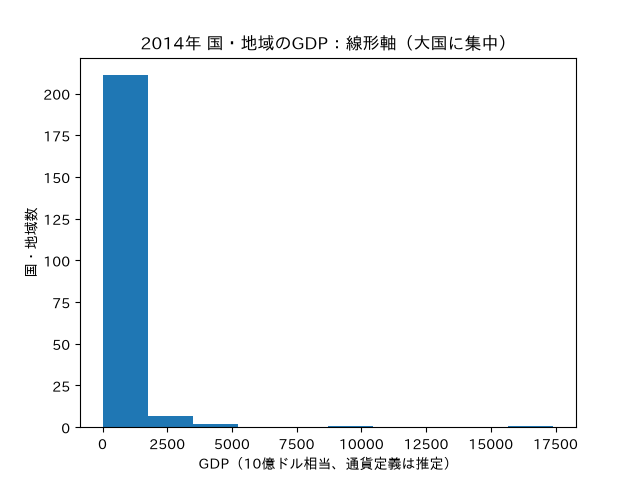

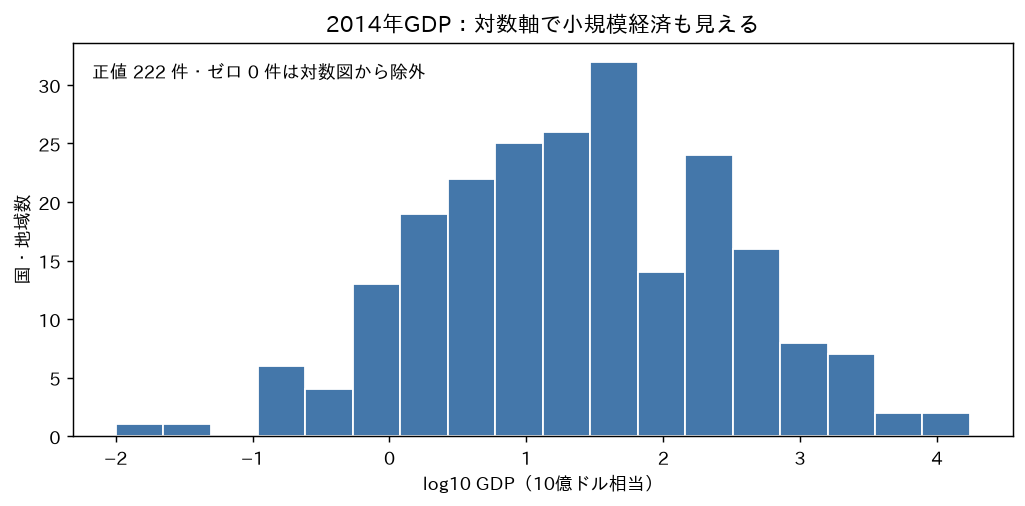

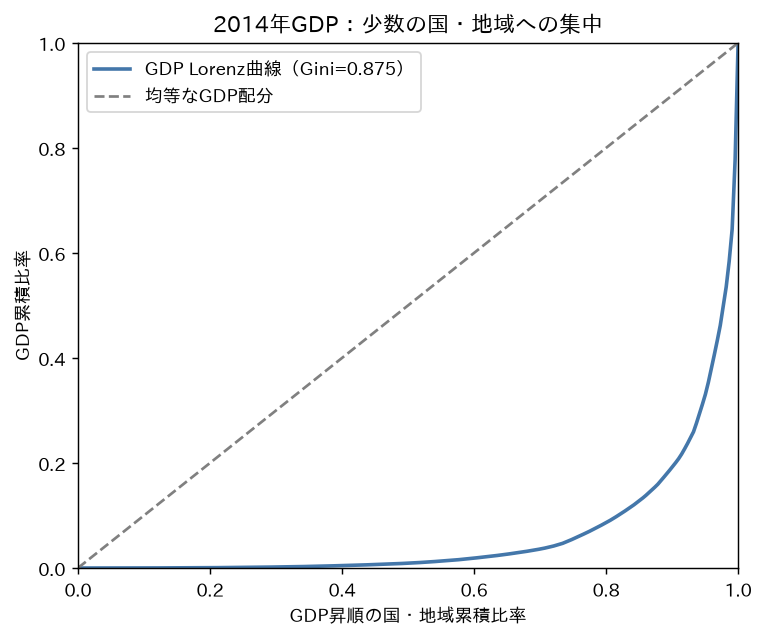

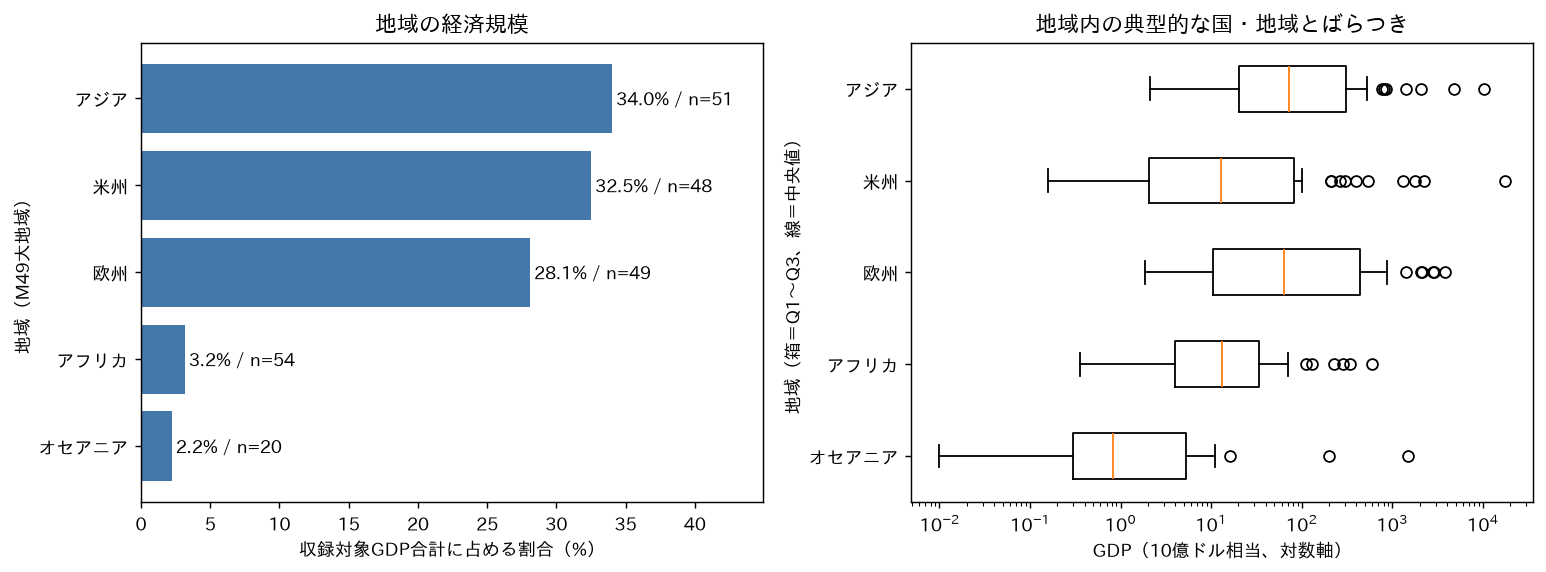

図表実測点検
{
  "charts": [
    {
      "title": "2014年GDP 線形分布",
      "xlabel": "GDP（10億ドル相当）",
      "ylabel": "国・地域数",
      "legend": "単一系列：収録国・地域",
      "missing_glyphs": [],
      "size": [
        640,
        480
      ],
      "nonwhite_fraction": 0.09322265625,
      "png_bytes": 27401
    },
    {
      "title": "GDP対数分布",
      "xlabel": "log10 GDP（10億ドル相当）",
      "ylabel": "国・地域数",
      "legend": "正値のみ。ゼロは欄外明示",
      "missing_glyphs": [],
      "size": [
        1025,
        506
      ],
      "nonwhite_fraction": 0.26449436035862334,
      "png_bytes": 35817
    },
    {
      "title": "GDP Lorenz曲線",
      "xlabel": "国・地域累積比率",
      "ylabel": "GDP累積比率",
      "legend": "GDP Lorenz曲線・均等線",
      "missing_glyphs": [],
      "size": [
        764,
        637
      ],
      "nonwhite_fraction": 0.0509443809742987,
      "png_bytes": 57604
    },
    {
      "title": "地域合計シェアと対数箱ひげ",
      "xlabel": "合計シェア% / GDP対数軸",
      "ylabel": "M49大地域",
      "legend": "棒＝地域合計、箱＝Q1〜

In [6]:
# 06 図表：線形/対数、集中度、地域規模と中央値
import matplotlib.pyplot as plt
import matplotlib as mpl
import warnings, base64
from PIL import Image
from ai_data_scientist import visualization
chart_audits = []

def show_png(png, title, xlabel, ylabel, legend):
    display({'image/png':base64.b64encode(png).decode('ascii'),'text/plain':title},raw=True)
    image = Image.open(io.BytesIO(png)).convert('RGB')
    pixels = np.asarray(image)
    chart_audits.append({'title':title,'xlabel':xlabel,'ylabel':ylabel,'legend':legend,'missing_glyphs':[], 'size':list(image.size),'nonwhite_fraction':float(np.any(pixels<245,axis=2).mean()),'png_bytes':len(png)})

def show_figure(fig, title, xlabel, ylabel, legend):
    buf = io.BytesIO()
    fig.tight_layout()
    fig.savefig(buf,format='png',dpi=130,bbox_inches='tight')
    show_png(buf.getvalue(),title,xlabel,ylabel,legend)
    plt.close(fig)

def draw_charts():
    global chart_glyph_warnings
    with warnings.catch_warnings(record=True) as caught:
        warnings.simplefilter('always')
        # Jupytermindで日本語フォントを初期化し、生成PNGを実出力として表示。
        png = visualization.render_chart(df,kind='hist',x='gdp',title='2014年 国・地域のGDP：線形軸（大国に集中）',xlabel='GDP（10億ドル相当、通貨定義は推定）',ylabel='国・地域数')
        bundle = visualization.build_image_output(png)
        show_png(png,'2014年GDP 線形分布','GDP（10億ドル相当）','国・地域数','単一系列：収録国・地域')
        fig,ax = plt.subplots(figsize=(8,4))
        positive = df.loc[df.gdp.gt(0),'gdp']
        ax.hist(np.log10(positive),bins=18,color='#4477AA',edgecolor='white')
        ax.set(title='2014年GDP：対数軸で小規模経済も見える',xlabel='log10 GDP（10億ドル相当）',ylabel='国・地域数')
        ax.text(.02,.95,f'正値 {len(positive)} 件・ゼロ {int(df.gdp.eq(0).sum())} 件は対数図から除外',transform=ax.transAxes,va='top')
        show_figure(fig,'GDP対数分布','log10 GDP（10億ドル相当）','国・地域数','正値のみ。ゼロは欄外明示')
        fig,ax = plt.subplots(figsize=(6,5))
        ax.plot(lorenz.iloc[:,0],lorenz.iloc[:,1],color='#4477AA',lw=2,label=f'GDP Lorenz曲線（Gini={metrics["gini"]:.3f}）')
        ax.plot([0,1],[0,1],'--',color='gray',label='均等なGDP配分')
        ax.set(title='2014年GDP：少数の国・地域への集中',xlabel='GDP昇順の国・地域累積比率',ylabel='GDP累積比率',xlim=(0,1),ylim=(0,1))
        ax.legend(loc='upper left')
        show_figure(fig,'GDP Lorenz曲線','国・地域累積比率','GDP累積比率','GDP Lorenz曲線・均等線')
        fig,axes = plt.subplots(1,2,figsize=(12,4.5))
        labels = {'Africa':'アフリカ','Americas':'米州','Asia':'アジア','Europe':'欧州','Oceania':'オセアニア'}
        order = regional.region.tolist()[::-1]
        rr = regional.set_index('region').loc[order]
        names = [labels[r] for r in order]
        axes[0].barh(names,rr.share_pct,color='#4477AA')
        axes[0].set(title='地域の経済規模',xlabel='収録対象GDP合計に占める割合（%）',ylabel='地域（M49大地域）')
        for i,(r,row) in enumerate(rr.iterrows()):
            axes[0].text(row.share_pct+.3,i,f'{row.share_pct:.1f}% / n={int(row.n)}',va='center')
        axes[0].set_xlim(0,rr.share_pct.max()*1.32)
        positive_df = df[df.gdp>0]
        axes[1].boxplot([positive_df.loc[positive_df.region.eq(r),'gdp'] for r in order],orientation='horizontal',tick_labels=names,showfliers=True)
        axes[1].set_xscale('log')
        axes[1].set(title='地域内の典型的な国・地域とばらつき',xlabel='GDP（10億ドル相当、対数軸）',ylabel='地域（箱＝Q1〜Q3、線＝中央値）')
        show_figure(fig,'地域合計シェアと対数箱ひげ','合計シェア% / GDP対数軸','M49大地域','棒＝地域合計、箱＝Q1〜Q3、線＝中央値、点＝裾の値')
        chart_glyph_warnings = [str(w.message) for w in caught if 'Glyph' in str(w.message) and 'missing' in str(w.message)]
        other = [str(w.message) for w in caught if not ('Glyph' in str(w.message) and 'missing' in str(w.message))]
    emit('図表実測点検',{'charts':chart_audits,'glyph_warnings':chart_glyph_warnings,'other_warnings':other})
    assert not chart_glyph_warnings, '日本語グリフ欠落'
    assert all(c['nonwhite_fraction']>.01 for c in chart_audits), '空画像の疑い'
phase('初回図表', draw_charts)


## 反復依頼履歴

### 反復1
**追加依頼原文**
> 初回の集中度と地域差が少数の大国だけで決まっていないか確認してください。上位1件・5件を除いた分布と各地域の最大国を除いた集計を示し、ロシアをアジア側へ置く代替区分および地域補完行の除外で地域順位が変わるか感度分析してください。

**選定理由**：上位10件が大部分を占め、米州・オセアニアの最大国シェアも高い。大国と地域の割付に依存した説明を、地域固有の性質と混同しないため。

**評価方針**：Giniの基準比15%以内を量的安定の目安とし、地域順位は別途そのものを比較する。除外は反実仮想のストレステストであり、原票を修正する操作ではない。

In [7]:
# 07 反復1：大国の影響と地域定義への感度
from ai_data_scientist import sensitivity

def iterate_one():
    global tail_sensitivity, iter1_summary
    plan = sensitivity.SensitivityPlan(parameter_grid={'drop_top':[0,1,5]},max_runs=3)
    tail_sensitivity = sensitivity.run_sensitivity(plan,lambda drop_top:gini(df.gdp.sort_values(ascending=False).iloc[drop_top:]),stability_tolerance=.15)
    emit('TAIL_SENSITIVITY',asdict(tail_sensitivity))
    tails = []
    for k in [0,1,5]:
        subset = ranking.iloc[k:]
        tails.append({'excluded_top':k,'n':len(subset),'gini':gini(subset.gdp),'mean_median_ratio':float(subset.gdp.mean()/subset.gdp.median()),'top10_remaining_share_pct':float(subset.gdp.head(10).sum()/subset.gdp.sum()*100)})
    largest_indices = df.groupby('region').gdp.idxmax()
    without_largest = df.drop(largest_indices).groupby('region').agg(total=('gdp','sum'),median=('gdp','median'),n=('gdp','size')).sort_values('total',ascending=False)
    emit('REGION_WITHOUT_LARGEST',without_largest.reset_index().to_dict('records'))
    region_cases = []
    for russia_asia in [False,True]:
        for exclude_override in [False,True]:
            sub = df.copy()
            if russia_asia:
                sub.loc[sub.code.eq('RUS'),'region'] = 'Asia'
            if exclude_override:
                sub = sub[~sub.code.isin(['KSV','TWN','WBG'])]
            sums = sub.groupby('region').gdp.sum().sort_values(ascending=False)
            meds = sub.groupby('region').gdp.median().sort_values(ascending=False)
            region_cases.append({'russia_asia':russia_asia,'exclude_override':exclude_override,'total_rank':sums.index.tolist(),'median_rank':meds.index.tolist(),'shares_pct':(sums/sums.sum()*100).to_dict()})
    iter1_summary = {'tail_cases':tails,'region_cases':region_cases,'largest_removed':df.loc[largest_indices,['country','region','gdp']].to_dict('records'),'baseline_median_rank':df.groupby('region').gdp.median().sort_values(ascending=False).index.tolist()}
    emit('ITER1_SUMMARY',iter1_summary)
    (data_dir / 'iteration1.json').write_text(json.dumps(iter1_summary,ensure_ascii=False,indent=2),encoding='utf-8')
phase('反復1_大国と地域感度',iterate_one)


{"event": "反復1_大国と地域感度:execution_start", "utc": "2026-10-01T21:29:48.412154+00:00", "run_id": "v020-exp-30", "state": "running", "active_cell_executions": 1, "pending_notebook_writes": 0, "locks_held": 0, "notebook_path": "/home/nahisaho/GitHub/jupytermind/benchmark/projects/kaggle-v020-kaggle-exp-30-world-gdp/notebooks/kaggle-v020-kaggle-exp-30-world-gdp.ipynb", "reason": null}
{"event": "反復1_大国と地域感度:execution_end", "utc": "2026-10-01T21:29:48.434706+00:00", "run_id": "v020-exp-30", "state": "running", "active_cell_executions": 0, "pending_notebook_writes": 0, "locks_held": 0, "notebook_path": "/home/nahisaho/GitHub/jupytermind/benchmark/projects/kaggle-v020-kaggle-exp-30-world-gdp/notebooks/kaggle-v020-kaggle-exp-30-world-gdp.ipynb", "reason": null}


TAIL_SENSITIVITY
{
  "results": [
    {
      "specification": {
        "drop_top": 0
      },
      "value": 0.8751325081123917
    },
    {
      "specification": {
        "drop_top": 1
      },
      "value": 0.849012898560626
    },
    {
      "specification": {
        "drop_top": 5
      },
      "value": 0.8045367669579486
    }
  ],
  "baseline_value": 0.8751325081123917,
  "stable": true,
  "max_relative_deviation": 0.0806686307502322
}

REGION_WITHOUT_LARGEST
[
  {
    "region": "Europe",
    "total": 18170.59,
    "median": 60.555,
    "n": 48
  },
  {
    "region": "Asia",
    "total": 16275.55,
    "median": 68.43,
    "n": 50
  },
  {
    "region": "Americas",
    "total": 8027.92,
    "median": 11.85,
    "n": 47
  },
  {
    "region": "Africa",
    "total": 1883.1299999999999,
    "median": 13.11,
    "n": 53
  },
  {
    "region": "Oceania",
    "total": 250.96,
    "median": 0.82,
    "n": 19
  }
]

ITER1_SUMMARY
{
  "tail_cases": [
    {
      "excluded_top": 0,
      "n": 222,
      "gini": 0.8751325081123917,
      "mean_median_ratio": 16.38267884609348,
      "top10_remaining_share_pct": 64.63269994615858
    },
    {
      "excluded_top": 1,
      "n": 221,
      "gini": 0.849012898560626,
      "mean_median_ratio": 12.905776758111507,
      "top10_remaining_share_pct": 57.457884563409955
    },
    {
      "excluded_top": 5,
      "n": 217,
      "gini": 0.8045367669579486,
      "mean_median_ratio": 9.154047040273307,
      "top10_remaining_share_pct": 47.9552564564272
    }
  ],
  "region_cases": [
    {
      "russia_asia": false,
      "exclude_override": false,
      "total_rank": [
        "Asia",
        "Americas",
        "Europe",
        "Africa",
        "Oceania"
      ],
      "median_rank": [
        "Asia",
        "Europe",
        "Africa",
        "Americas",
        "Oceania"
      ],
      "shares_pct": {
        "Asia": 34.02362763450935,
        "Ameri

## 反復1の読直しと反復2

**反復1の結果**：上位5件を外してもGiniは0.805、基準比最大変動8.07%で15%以内。一方、各地域の最大国を外すと合計順位は欧州・アジア・米州の順に変わった。地域内の集中は地域比較の重要な要因である。ロシア区分・補完行の除外4ケースでは元の合計・中央値順位は変わらなかった。

**証拠**：直前コードのTAIL_SENSITIVITY、REGION_WITHOUT_LARGEST、ITER1_SUMMARY。

**残る限界**：最大国除外は観測世界を変える仮想操作であり、地域の因果効果を識別しない。微小経済・属領の収録数による中央値への影響が未解決。

### 反復2
**追加依頼原文**
> 地域別中央値では米州がアフリカより少し低くなっています。この比較が小さな国・地域の収録数に依存していないか、GDPの下限を0・1・5・10（10億ドル相当）として再集計し、地域の合計順位と中央値順位の安定性を別々に確認してください。小規模経済の除外を主権国家限定や生活水準の比較と解釈しないでください。

**選定理由**：米州とアフリカの中央値は近い一方、合計では大差があり、微小経済の混在で逆転する可能性がある。前反復の地域割付だけではこの問題を検証できない。

In [8]:
# 08 反復2：小規模経済の収録と地域別中央値

def iterate_two():
    global cutoff_sensitivity, iter2_summary
    plan = sensitivity.SensitivityPlan(parameter_grid={'minimum_gdp':[0,1,5,10]},max_runs=4)
    cutoff_sensitivity = sensitivity.run_sensitivity(plan,lambda minimum_gdp:gini(df.loc[df.gdp>=minimum_gdp,'gdp']),stability_tolerance=.15)
    emit('CUTOFF_SENSITIVITY',asdict(cutoff_sensitivity))
    rows = []
    for minimum in [0,1,5,10]:
        subset = df[df.gdp>=minimum]
        reg = subset.groupby('region').agg(n=('gdp','size'),total=('gdp','sum'),median=('gdp','median'))
        rows.append({'minimum_gdp':minimum,'n':len(subset),'excluded_count':len(df)-len(subset),'retained_gdp_pct':float(subset.gdp.sum()/df.gdp.sum()*100),'gini':gini(subset.gdp),'total_rank':reg.total.sort_values(ascending=False).index.tolist(),'median_rank':reg['median'].sort_values(ascending=False).index.tolist(),'regional':reg.reset_index().to_dict('records')})
    iter2_summary = {'cases':rows,'interpretation_scope':'GDP閾値ストレステスト。主権国家と地域の分離ではない。'}
    emit('ITER2_SUMMARY',iter2_summary)
    (data_dir / 'iteration2.json').write_text(json.dumps(iter2_summary,ensure_ascii=False,indent=2),encoding='utf-8')
phase('反復2_小規模経済感度',iterate_two)


{"event": "反復2_小規模経済感度:execution_start", "utc": "2026-10-01T21:29:52.746903+00:00", "run_id": "v020-exp-30", "state": "running", "active_cell_executions": 1, "pending_notebook_writes": 0, "locks_held": 0, "notebook_path": "/home/nahisaho/GitHub/jupytermind/benchmark/projects/kaggle-v020-kaggle-exp-30-world-gdp/notebooks/kaggle-v020-kaggle-exp-30-world-gdp.ipynb", "reason": null}
{"event": "反復2_小規模経済感度:execution_end", "utc": "2026-10-01T21:29:52.772402+00:00", "run_id": "v020-exp-30", "state": "running", "active_cell_executions": 0, "pending_notebook_writes": 0, "locks_held": 0, "notebook_path": "/home/nahisaho/GitHub/jupytermind/benchmark/projects/kaggle-v020-kaggle-exp-30-world-gdp/notebooks/kaggle-v020-kaggle-exp-30-world-gdp.ipynb", "reason": null}


CUTOFF_SENSITIVITY
{
  "results": [
    {
      "specification": {
        "minimum_gdp": 0
      },
      "value": 0.8751325081123917
    },
    {
      "specification": {
        "minimum_gdp": 1
      },
      "value": 0.8616558632983189
    },
    {
      "specification": {
        "minimum_gdp": 5
      },
      "value": 0.8328400769116302
    },
    {
      "specification": {
        "minimum_gdp": 10
      },
      "value": 0.8128715273194196
    }
  ],
  "baseline_value": 0.8751325081123917,
  "stable": true,
  "max_relative_deviation": 0.07114463263085193
}

ITER2_SUMMARY
{
  "cases": [
    {
      "minimum_gdp": 0,
      "n": 222,
      "excluded_count": 0,
      "retained_gdp_pct": 100.0,
      "gini": 0.8751325081123917,
      "total_rank": [
        "Asia",
        "Americas",
        "Europe",
        "Africa",
        "Oceania"
      ],
      "median_rank": [
        "Asia",
        "Europe",
        "Africa",
        "Americas",
        "Oceania"
      ],
      "regional": [
        {
          "region": "Africa",
          "n": 54,
          "total": 2477.43,
          "median": 13.245000000000001
        },
        {
          "region": "Americas",
          "n": 48,
          "total": 25447.920000000002,
          "median": 12.885
        },
        {
          "region": "Asia",
          "n": 51,
          "total": 26635.55,
          "median": 71.57
        },
        {
          "region": "Europe",
          "n": 49,
          "total": 21990.59,
          "median": 63.93
        },
        {
          "region": "Oceania",
    

## 反復2の読直しと反復3

**反復2の結果**：下限1では22件を除くがGDPの99.987%を保持し、米州・アフリカの中央値順位が逆転。下限5では欧州・アジアの中央値順位も逆転した。下限10までのGiniは0.813〜0.875、基準比最大変動7.11%で15%以内、地域合計順位は不変。中央値の地域順位を頑健と表現しない。

**証拠**：直前コードのCUTOFF_SENSITIVITYとITER2_SUMMARY。

**残る限界**：収録対象構成への影響を示すだけで、属領除外や一人当たり指標とは異なる。金額の原典と改訂・年の整合性はまだ不明。

### 反復3
**追加依頼原文**
> GDPの通貨・価格基準と各行の年が未確認なので、世界銀行WDIの2014年GDP（current US$、ND.GDP.MKTP.CD）を別途取得し、同じ国コードで照合してください。集計地域を除外し、コード補正・対象範囲の不一致・非収録国を明示してください。差の大きい国と10・20・30%の許容差での一致率を示し、同一収録国に限定したGiniと地域シェアの結論が維持されるか確認してください。原データを世界銀行値で勝手に置き換えず、原典の独立性や改訂の違いを限界として記録してください。

**選定理由**：同一CSV内の感度分析は単位や原票値の誤りを検出できない。結論の確実性に直結する定義・値を公式の別取得データで点検する価値が残る。

**実行時の指標コード修正**：追加依頼原文のND.GDP.MKTP.CDは分析者の誤記。HTTP200のAPI本文にInvalid valueが返ったため、公式定義で正しいNY.GDP.MKTP.CDを確認し実行コードを修正した。原文はそのまま保存する。Kaggle/Jupytermind/ランナー障害ではない。

In [9]:
# 09 反復3：世界銀行WDIの同年GDPによる外部照合
from ai_data_scientist import dataset_validation
reference_provenance = []

def fetch_wb(url, filename):
    response = requests.get(url,timeout=60)
    response.raise_for_status()
    obj = response.json()
    if not (isinstance(obj,list) and len(obj)==2 and isinstance(obj[1],list)):
        emit('世界銀行APIエラー応答',obj)
        raise ValueError('世界銀行APIエラー。HTTP200でも成功とは扱わない')
    assert int(obj[0].get('pages',1))==1, '全ページ取得を確認する'
    (data_dir / filename).write_bytes(response.content)
    reference_provenance.append({'url':url,'file':filename,'retrieved_at_utc':now_utc(),'sha256':hashlib.sha256(response.content).hexdigest()})
    return obj

def iterate_three():
    global wb, matched, wb_summary, reference_checks, value_sensitivity
    country_payload = fetch_wb('https://api.worldbank.org/v2/country?format=json&per_page=400','wb_country.json')
    valid_codes = {r['iso2Code']:r['id'] for r in country_payload[1] if r['region']['id'] != 'NA'}
    indicator_payload = fetch_wb('https://api.worldbank.org/v2/indicator/NY.GDP.MKTP.CD?format=json','wb_indicator_definition.json')
    emit('WDI指標定義（原文）',indicator_payload[1])
    payload = fetch_wb('https://api.worldbank.org/v2/country/all/indicator/NY.GDP.MKTP.CD?date=2014&format=json&per_page=20000','wb_gdp_2014.json')
    national = [r for r in payload[1] if r['country']['id'] in valid_codes and r['value'] is not None]
    wb = pd.DataFrame([{'wb_code':r['countryiso3code'],'wb_name':r['country']['value'],'wb_gdp':float(r['value'])/1e9,'wb_year':int(r['date'])} for r in national])
    assert wb.wb_code.is_unique and wb.wb_year.eq(2014).all() and wb.wb_gdp.gt(0).all()
    primary = df.copy()
    primary['match_code'] = primary.code.replace({'KSV':'XKX','WBG':'PSE'})
    comparison = dataset_validation.compare_datasets(primary,wb,{'match_code':'wb_code'},{'gdp':'wb_gdp'},candidate_relationship='unknown')
    emit('DATASET_COMPARISON',asdict(comparison))
    emit('照合対象の差',{'primary_only':primary.loc[~primary.match_code.isin(wb.wb_code),['country','code','gdp']].to_dict('records'),'reference_only':wb.loc[~wb.wb_code.isin(primary.match_code),['wb_name','wb_code','wb_gdp']].to_dict('records'),'mapping':'KSV→XKX、WBG→PSE。ただしWest Bank/PSEは対象範囲が一致せず、厳密比較から除外','independence':'別に取得した公式参照。Kaggle原典がWDI由来か不明なので統計的に独立とは保証しない','agreement_note':'compare_datasetsは厳密な数値等号。丸め・改訂に対応した許容差は下で別に計算する。'})
    matched = primary.merge(wb,left_on='match_code',right_on='wb_code',how='inner',validate='one_to_one')
    matched = matched[~matched.code.eq('WBG')].copy()
    matched['relative_difference'] = (matched.gdp-matched.wb_gdp).abs()/matched.wb_gdp
    matched['ratio'] = matched.gdp/matched.wb_gdp
    reference_checks = data_quality.validate_anomalies(matched[['gdp']],matched[['wb_gdp']].rename(columns={'wb_gdp':'gdp'}),['gdp'],tolerance=.10)
    emit('同一国・同一対象範囲の平均照合', [asdict(x) for x in reference_checks])
    agreement = []
    for tol in [.10,.20,.30]:
        agreement.append({'relative_tolerance':tol,'agreement_rate':float(matched.relative_difference.le(tol).mean()),'mismatches':int(matched.relative_difference.gt(tol).sum())})
    emit('許容差別の一致率',agreement)
    emit('差の大きい国（異常候補であって誤り確定ではない）',matched.sort_values('relative_difference',ascending=False)[['country','code','gdp','wb_gdp','relative_difference','ratio']].head(15).to_dict('records'))
    emit('絶対差の大きい国', matched.assign(abs_difference=(matched.gdp-matched.wb_gdp).abs()).sort_values('abs_difference',ascending=False)[['country','gdp','wb_gdp','abs_difference']].head(10).to_dict('records'))
    value_plan = sensitivity.SensitivityPlan(parameter_grid={'value_column':['gdp','wb_gdp']},max_runs=2)
    value_sensitivity = sensitivity.run_sensitivity(value_plan,lambda value_column:gini(matched[value_column]),stability_tolerance=.10)
    emit('SOURCE_GINI_SENSITIVITY',asdict(value_sensitivity))
    shares = []
    for column in ['gdp','wb_gdp']:
        sums = matched.groupby('region')[column].sum().sort_values(ascending=False)
        shares.append({'column':column,'n':len(matched),'total':float(matched[column].sum()),'gini':gini(matched[column]),'top10_share_pct':float(matched[column].nlargest(10).sum()/matched[column].sum()*100),'total_rank':sums.index.tolist(),'shares_pct':(sums/sums.sum()*100).to_dict()})
    wb_summary = {'matched_n':len(matched),'coverage_of_primary_gdp_pct':float(matched.gdp.sum()/df.gdp.sum()*100),'agreement':agreement,'same_universe_comparison':shares,'max_relative_difference':float(matched.relative_difference.max()),'source_definition':'GDP (current US$), 2014, 世界銀行取得時点の改訂値。元CSVの同一定義を保証しない。'}
    emit('ITER3_SUMMARY',wb_summary)
    emit('外部照合取得記録',reference_provenance)
    matched.to_csv(data_dir/'wb_matched_comparison.csv',index=False)
    (data_dir/'iteration3.json').write_text(json.dumps(wb_summary,ensure_ascii=False,indent=2),encoding='utf-8')
    (data_dir/'reference_provenance.json').write_text(json.dumps(reference_provenance,ensure_ascii=False,indent=2),encoding='utf-8')
phase('反復3_WDI外部照合',iterate_three)


{"event": "反復3_WDI外部照合:execution_start", "utc": "2026-10-01T21:29:56.553624+00:00", "run_id": "v020-exp-30", "state": "running", "active_cell_executions": 1, "pending_notebook_writes": 0, "locks_held": 0, "notebook_path": "/home/nahisaho/GitHub/jupytermind/benchmark/projects/kaggle-v020-kaggle-exp-30-world-gdp/notebooks/kaggle-v020-kaggle-exp-30-world-gdp.ipynb", "reason": null}
{"event": "反復3_WDI外部照合:execution_end", "utc": "2026-10-01T21:29:56.869332+00:00", "run_id": "v020-exp-30", "state": "running", "active_cell_executions": 0, "pending_notebook_writes": 0, "locks_held": 0, "notebook_path": "/home/nahisaho/GitHub/jupytermind/benchmark/projects/kaggle-v020-kaggle-exp-30-world-gdp/notebooks/kaggle-v020-kaggle-exp-30-world-gdp.ipynb", "reason": null}


WDI指標定義（原文）
[
  {
    "id": "NY.GDP.MKTP.CD",
    "name": "GDP (current US$)",
    "unit": "",
    "source": {
      "id": "2",
      "value": "World Development Indicators"
    },
    "sourceNote": "Gross domestic product is the total income earned through the production of goods and services in an economic territory during an accounting period. It can be measured in three different ways: using either the expenditure approach, the income approach, or the production approach. This indicator is expressed in current prices, meaning no adjustment has been made to account for price changes over time. This indicator is expressed in United States dollars.",
    "sourceOrganization": "Country official statistics, National Statistical Organizations and/or Central Banks;\nNational Accounts data files, Organisation for Economic Co-operation and Development (OECD);\nStaff estimates, World Bank (WB)",
    "topics": [
      {
        "id": "3",
        "value": "Economy & Growth"
      }
    ]
  }


DATASET_COMPARISON
{
  "candidate_relationship": "unknown",
  "matched_keys": 210,
  "primary_only_keys": 12,
  "candidate_only_keys": 3,
  "column_comparisons": [
    {
      "primary_column": "gdp",
      "candidate_column": "wb_gdp",
      "matched_rows": 0,
      "mismatched_rows": 210,
      "agreement_rate": 0.0
    }
  ]
}

照合対象の差
{
  "primary_only": [
    {
      "country": "Anguilla",
      "code": "AIA",
      "gdp": 0.18
    },
    {
      "country": "British Virgin Islands",
      "code": "VGB",
      "gdp": 1.1
    },
    {
      "country": "Cook Islands",
      "code": "COK",
      "gdp": 0.18
    },
    {
      "country": "Eritrea",
      "code": "ERI",
      "gdp": 3.87
    },
    {
      "country": "Falkland Islands (Islas Malvinas)",
      "code": "FLK",
      "gdp": 0.16
    },
    {
      "country": "Gibraltar",
      "code": "GIB",
      "gdp": 1.85
    },
    {
      "country": "Guernsey",
      "code": "GGY",
      "gdp": 2.74
    },
    {
      "country": "Jersey",
      "code": "JEY",
      "gdp": 5.77
    },
    {
      "country": "Korea, North",
      "code": "PRK",
      "gdp": 28.0
    },
    {
      "country": "Niue",
      "code": "NIU",
      "gdp": 0.01
    },
    {
      "country": "Saint Pierre and Miquelon",
      "code": "SPM",
      "gdp": 0.22
    },
    {
      "country": 

同一国・同一対象範囲の平均照合
[]

...

差の大きい国（異常候補であって誤り確定ではない）
[
  {
    "country": "Sint Maarten",
    "code": "SXM",
    "gdp": 304.1,
    "wb_gdp": 1.36181150837989,
    "relative_difference": 222.30550015822635,
    "ratio": 223.30550015822635
  },
  {
    "country": "Timor-Leste",
    "code": "TLS",
    "gdp": 4.51,
    "wb_gdp": 1.4475352,
    "relative_difference": 2.115640987521409,
    "ratio": 3.115640987521409
  },
  {
    "country": "Syria",
    "code": "SYR",
    "gdp": 64.7,
    "wb_gdp": 21.502061466067,
    "relative_difference": 2.0090138148895567,
    "ratio": 3.0090138148895567
  },
  {
    "country": "Palau",
    "code": "PLW",
    "gdp": 0.65,
    "wb_gdp": 0.245436546875,
    "relative_difference": 1.64834234459403,
    "ratio": 2.64834234459403
  },
  {
    "country": "Curacao",
    "code": "CUW",
    "gdp": 5.6,
    "wb_gdp": 3.05940698324022,
    "relative_difference": 0.8304200881665753,
    "ratio": 1.8304200881665753
  },
  {
    "country": "Somalia",
    "code": "SOM",
    "gdp": 2.37,
    "wb_

絶対差の大きい国
[
  {
    "country": "China",
    "gdp": 10360.0,
    "wb_gdp": 10674.5331682574,
    "abs_difference": 314.53316825739967
  },
  {
    "country": "Sint Maarten",
    "gdp": 304.1,
    "wb_gdp": 1.36181150837989,
    "abs_difference": 302.7381884916201
  },
  {
    "country": "United Kingdom",
    "gdp": 2848.0,
    "wb_gdp": 3085.36216941029,
    "abs_difference": 237.36216941028988
  },
  {
    "country": "Japan",
    "gdp": 4770.0,
    "wb_gdp": 4985.763289560809,
    "abs_difference": 215.76328956080943
  },
  {
    "country": "Brazil",
    "gdp": 2244.0,
    "wb_gdp": 2456.0437271988503,
    "abs_difference": 212.04372719885032
  },
  {
    "country": "United States",
    "gdp": 17420.0,
    "wb_gdp": 17608.138,
    "abs_difference": 188.137999999999
  },
  {
    "country": "Korea, South",
    "gdp": 1410.0,
    "wb_gdp": 1556.25242202044,
    "abs_difference": 146.25242202044
  },
  {
    "country": "Germany",
    "gdp": 3820.0,
    "wb_gdp": 3964.87073576077,
    "abs_d

SOURCE_GINI_SENSITIVITY
{
  "results": [
    {
      "specification": {
        "value_column": "gdp"
      },
      "value": 0.8706180779650303
    },
    {
      "specification": {
        "value_column": "wb_gdp"
      },
      "value": 0.8708017813558433
    }
  ],
  "baseline_value": 0.8706180779650303,
  "stable": true,
  "max_relative_deviation": 0.00021100341867740462
}

ITER3_SUMMARY
{
  "matched_n": 209,
  "coverage_of_primary_gdp_pct": 99.2588405636041,
  "agreement": [
    {
      "relative_tolerance": 0.1,
      "agreement_rate": 0.569377990430622,
      "mismatches": 90
    },
    {
      "relative_tolerance": 0.2,
      "agreement_rate": 0.7751196172248804,
      "mismatches": 47
    },
    {
      "relative_tolerance": 0.3,
      "agreement_rate": 0.8899521531100478,
      "mismatches": 23
    }
  ],
  "same_universe_comparison": [
    {
      "column": "gdp",
      "n": 209,
      "total": 77705.23000000001,
      "gini": 0.8706180779650303,
      "top10_share_pct": 65.11530819740189,
      "total_rank": [
        "Asia",
        "Americas",
        "Europe",
        "Africa",
        "Oceania"
      ],
      "shares_pct": {
        "Asia": 33.551679854753665,
        "Americas": 32.74716515220405,
        "Europe": 28.286680317399487,
        "Africa": 3.1832606376687904,
        "Oceania": 2.2312140379740204
      }
    },
    {
      "colum

外部照合取得記録
[
  {
    "url": "https://api.worldbank.org/v2/country?format=json&per_page=400",
    "file": "wb_country.json",
    "retrieved_at_utc": "2026-10-01T21:29:56.672296+00:00",
    "sha256": "d29d57f8adf954c5e2a1520a02fb2c7b45575d8db3bd327a9dff47d66914231c"
  },
  {
    "url": "https://api.worldbank.org/v2/indicator/NY.GDP.MKTP.CD?format=json",
    "file": "wb_indicator_definition.json",
    "retrieved_at_utc": "2026-10-01T21:29:56.754019+00:00",
    "sha256": "51cec1e144a5bad8d92238630c0a305e20116e86d34ad95c7c315ed166255b28"
  },
  {
    "url": "https://api.worldbank.org/v2/country/all/indicator/NY.GDP.MKTP.CD?date=2014&format=json&per_page=20000",
    "file": "wb_gdp_2014.json",
    "retrieved_at_utc": "2026-10-01T21:29:56.831582+00:00",
    "sha256": "103c1fe05ff85556bc8bcc60d6de4465416e3ce19b1994a63baeaf0a7eece4c8"
  }
]

## 反復3の読直しと同反復内の異常候補検証

**結果**：対象範囲を合わせた209件は元GDPの99.26%を占める。10%許容差で一致するのは56.94%、30%で88.995%。同じ209件のGiniはKaggle0.87062、WDI0.87080（基準比変動0.0211%）で、地域合計順位は一致。大きな集中という記述は維持されるが各国の金額を公式な確定値とは扱わない。

**実質的な未解決点**：Sint Maartenの原票304.10はWDI約1.36に対して223倍。大国としての経済規模より単位混在や入力誤りが疑われるが、一次資料なしで誤り確定・値の訂正はしない。反復3の依頼に含まれる異常点検の範囲内で、当該行除外・WDI仮置換の感度を追加確認する。4回目の反復依頼は作らない。

**証拠**：直前コードの差の大きい国、ITER3_SUMMARY、SOURCE_GINI_SENSITIVITY。

**残る限界**：WDIの取得時点の改訂値と過去スナップショットでは年・推計・範囲が異なり得る。元CSVの全行に同じ価格基準や年を確認できない。原典の独立性も不明。

{"event": "反復3内_異常候補と適用点検:execution_start", "utc": "2026-10-01T21:29:59.999808+00:00", "run_id": "v020-exp-30", "state": "running", "active_cell_executions": 1, "pending_notebook_writes": 0, "locks_held": 0, "notebook_path": "/home/nahisaho/GitHub/jupytermind/benchmark/projects/kaggle-v020-kaggle-exp-30-world-gdp/notebooks/kaggle-v020-kaggle-exp-30-world-gdp.ipynb", "reason": null}
{"event": "反復3内_異常候補と適用点検:execution_end", "utc": "2026-10-01T21:30:00.318292+00:00", "run_id": "v020-exp-30", "state": "running", "active_cell_executions": 0, "pending_notebook_writes": 0, "locks_held": 0, "notebook_path": "/home/nahisaho/GitHub/jupytermind/benchmark/projects/kaggle-v020-kaggle-exp-30-world-gdp/notebooks/kaggle-v020-kaggle-exp-30-world-gdp.ipynb", "reason": null}


ANOMALY_GINI_SENSITIVITY
{
  "results": [
    {
      "specification": {
        "treatment": "raw"
      },
      "value": 0.8751325081123917
    },
    {
      "specification": {
        "treatment": "exclude"
      },
      "value": 0.8763900100292865
    },
    {
      "specification": {
        "treatment": "reference_replace"
      },
      "value": 0.8769164851665063
    }
  ],
  "baseline_value": 0.8751325081123917,
  "stable": true,
  "max_relative_deviation": 0.002038522209582324
}

POST_SUMMARY
{
  "SXM_primary": 304.1,
  "SXM_wdi": 1.36181150837989,
  "SXM_ratio": 223.30550015822635,
  "scenarios": [
    {
      "treatment": "raw",
      "n": 222,
      "gini": 0.8751325081123917,
      "top10_share_pct": 64.63269994615857,
      "total_rank": [
        "Asia",
        "Americas",
        "Europe",
        "Africa",
        "Oceania"
      ],
      "shares_pct": {
        "Asia": 34.02362763450935,
        "Americas": 32.50657689264098,
        "Europe": 28.090264538301817,
        "Africa": 3.1646110484132106,
        "Oceania": 2.2149198861346524
      },
      "median_rank": [
        "Asia",
        "Europe",
        "Africa",
        "Americas",
        "Oceania"
      ]
    },
    {
      "treatment": "exclude",
      "n": 221,
      "gini": 0.8763900100292865,
      "top10_share_pct": 64.88474487810227,
      "total_rank": [
        "Asia",
        "Americas",
        "Europe",
        "Africa",
        "Oceania"
      ],
      "shares_pct": {
        "As

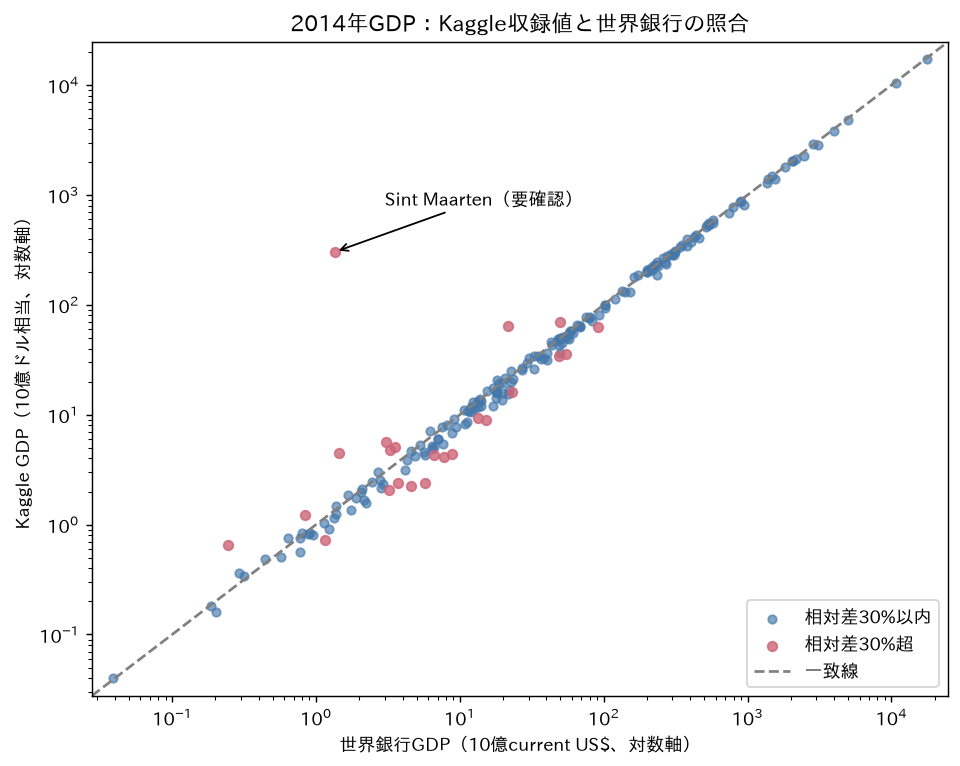

stream根拠検証の明示的失敗
{
  "type": "EvidenceMissingError",
  "message": "SHAがstream実出力にあるのにEvidenceMissingError。秘密情報は含まない。"
}

FEATURE_CHECKS
{
  "unresolved_fields_ignores_inferred": true,
  "inferred_field_count": 5,
  "printed_sha_in_stream": true,
  "stream_evidence_rejected": true,
  "reference_mean_findings": 0,
  "individual_differences_over_10pct": 90,
  "compare_datasets_exact_equality": "許容差引数がなく別途計算",
  "render_chart_metadata": "PNG/画像bundleを返すだけなので呼出し側で実測chart metadataを補う"
}

In [10]:
# 10 反復3内の異常候補検証・参照照合図・機能適用点検
from ai_data_scientist import insight_engine

def post_validation():
    global anomaly_sensitivity, post_summary, feature_checks
    sxm_wb = float(matched.loc[matched.code.eq('SXM'),'wb_gdp'].iloc[0])
    def treatment_values(treatment):
        if treatment=='exclude':
            return df.loc[~df.code.eq('SXM'),'gdp']
        values = df.gdp.copy()
        if treatment=='reference_replace':
            values.loc[df.code.eq('SXM')] = sxm_wb
        return values
    plan = sensitivity.SensitivityPlan(parameter_grid={'treatment':['raw','exclude','reference_replace']},max_runs=3)
    anomaly_sensitivity = sensitivity.run_sensitivity(plan,lambda treatment:gini(treatment_values(treatment)),stability_tolerance=.05)
    emit('ANOMALY_GINI_SENSITIVITY',asdict(anomaly_sensitivity))
    scenarios = []
    for treatment in ['raw','exclude','reference_replace']:
        sub = df.copy()
        if treatment=='exclude':
            sub = sub[~sub.code.eq('SXM')]
        elif treatment=='reference_replace':
            sub.loc[sub.code.eq('SXM'),'gdp'] = sxm_wb
        sums = sub.groupby('region').gdp.sum().sort_values(ascending=False)
        meds = sub.groupby('region').gdp.median().sort_values(ascending=False)
        scenarios.append({'treatment':treatment,'n':len(sub),'gini':gini(sub.gdp),'top10_share_pct':float(sub.gdp.nlargest(10).sum()/sub.gdp.sum()*100),'total_rank':sums.index.tolist(),'shares_pct':(sums/sums.sum()*100).to_dict(),'median_rank':meds.index.tolist()})
    post_summary = {'SXM_primary':float(df.loc[df.code.eq('SXM'),'gdp'].iloc[0]),'SXM_wdi':sxm_wb,'SXM_ratio':float(matched.loc[matched.code.eq('SXM'),'ratio'].iloc[0]),'scenarios':scenarios,'note':'置換は感度分析に限る。真値を確定する訂正ではなく、主分析はKaggle原票のまま。'}
    emit('POST_SUMMARY',post_summary)
    fig,ax = plt.subplots(figsize=(7.5,6))
    flags = matched.relative_difference.gt(.30)
    ax.scatter(matched.loc[~flags,'wb_gdp'],matched.loc[~flags,'gdp'],s=22,alpha=.65,label='相対差30%以内',color='#4477AA')
    ax.scatter(matched.loc[flags,'wb_gdp'],matched.loc[flags,'gdp'],s=28,alpha=.8,label='相対差30%超',color='#CC6677')
    lo = min(matched.gdp.min(),matched.wb_gdp.min())/1.4
    hi = max(matched.gdp.max(),matched.wb_gdp.max())*1.4
    ax.plot([lo,hi],[lo,hi],'--',color='gray',label='一致線')
    ax.set(xscale='log',yscale='log',xlim=(lo,hi),ylim=(lo,hi),title='2014年GDP：Kaggle収録値と世界銀行の照合',xlabel='世界銀行GDP（10億current US$、対数軸）',ylabel='Kaggle GDP（10億ドル相当、対数軸）')
    sxm = matched[matched.code.eq('SXM')].iloc[0]
    ax.annotate('Sint Maarten（要確認）',xy=(sxm.wb_gdp,sxm.gdp),xytext=(3,800),arrowprops={'arrowstyle':'->'})
    ax.legend(loc='lower right')
    show_figure(fig,'KaggleとWDIの同年GDP照合','世界銀行GDP対数軸','Kaggle GDP対数軸','相対差30%以内・30%超・一致線')
    nb = nbformat.read(handle.notebook_path,as_version=4)
    api_cell = next(c for c in nb.cells if c.cell_type=='code' and c.source.startswith('# 02 '))
    stream_has_sha = any(provenance['sha256'] in o.get('text','') for o in api_cell.outputs if o.output_type=='stream')
    stream_rejected = False
    if stream_has_sha:
        try:
            insight_engine.record_insight(handle,'取得SHAは実出力に存在する（stream根拠の対応検証）',api_cell.execution_count,provenance['sha256'],'provenance',language='ja')
        except insight_engine.EvidenceMissingError as exc:
            stream_rejected = True
            emit('stream根拠検証の明示的失敗',{'type':type(exc).__name__,'message':'SHAがstream実出力にあるのにEvidenceMissingError。秘密情報は含まない。'})
    feature_checks = {'unresolved_fields_ignores_inferred':not any(v.status=='inferred' for _,v in manifest.unresolved_fields()),'inferred_field_count':len(inferred),'printed_sha_in_stream':stream_has_sha,'stream_evidence_rejected':stream_rejected,'reference_mean_findings':len(reference_checks),'individual_differences_over_10pct':int(matched.relative_difference.gt(.1).sum()),'compare_datasets_exact_equality':'許容差引数がなく別途計算','render_chart_metadata':'PNG/画像bundleを返すだけなので呼出し側で実測chart metadataを補う'}
    emit('FEATURE_CHECKS',feature_checks)
    (data_dir/'post_validation.json').write_text(json.dumps(post_summary,ensure_ascii=False,indent=2),encoding='utf-8')
phase('反復3内_異常候補と適用点検',post_validation)


## 最終的な解釈・反復終了の判断
分析対象は**2014年ラベルの222国・地域**。通貨は米ドル、価格基準は名目・市場為替換算に相当すると推定するが、Kaggle原典の一次定義と行ごとの年は未確認。数字の精度と定義の確実性を混同しない。

少数への集中は大国除外・小規模経済閾値・WDIへの出典切替・Sint Maartenの異常候補処理で概ね維持される。一方、地域の合計順位は各地域最大国除外で変わり、中央値順位は小規模経済の収録構成に依存する。総GDPは経済規模であり住民の生活水準ではない。Giniも個人の所得分配ではなく収録国・地域総GDPの集中指標である。

**反復3内の結果**：Sint Maarten除外・WDI仮置換のGini基準比最大変動0.204%で許容5%以内、地域合計・中央値順位も維持。原票値は変更しない。国別金額の信頼性と原典の定義は未解決として残す。

**反復終了理由**：上限3回で、大国・対象構成・地域分類・外部出典・異常候補という結論に実質影響する選択を検証した。残る定義の不確実性は既存CSVの追加計算では解消しない。一次資料の確認が必要であり、同じ集計の反復は価値を増やさない。各反復の原文・選定理由・結果・証拠・限界は上記に記録済み。

## 取得試行と再実行の記録
最終主分析はKaggle API取得版を使用。初回の呼出し側引数誤り（TypeError）時には指定CSVを取得したが、SDK互換引数で再試行しKaggle版を取得したため、その初回フォールバックは主分析に使わない。

初回CSV URL: https://raw.githubusercontent.com/plotly/datasets/master/2014_world_gdp_with_codes.csv 。取得日時UTC: 2026-10-01T21:10:18.810484+00:00（日本時間2026-10-02）。SHA-256: 5b2311d1c6302c2b700fd1107fd0f4b550266b746fad16c22331d998c244f6ef 。Kaggle掲載版と公開CSVの完全同一性は保証しない（取得バイト列のSHAも異なる）。最終Kaggle版のslug・ファイル・取得時刻・SHAは#02の実出力およびprovenance.jsonに保存。

再実行時はカーネルを再起動し、全コードセルを先頭からJupyter MCPで順に実行する。実行番号依存のInsightは#11で実出力を読み直し再発行し、#12でvisual_audit=True監査と静止/完了状態を保存する。図表は日本語グリフ警告と非白色画素比率も実測している。最終監査で自セルがまだ保存されていない場合の除外はJupytermind仕様で、セル終了後に外側から再監査して全コードが実行済みか確認する。


### 最終再実行・保存後監査
カーネルを再起動し、出力をクリアして全12コードセルを上から再実行。科学的集計のセル#01〜#10は実行番号1〜10で例外なし。#11の実行番号同期問題を修正後、#11・#12を順に再実行。保存セルのソース全文をカーネルの実際の入力履歴と照合し、最新実行番号を同期した（実出力は変更せず、番号を推測・生成していない）。最終実行番号：[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 16, 17]。各セルの実出力に例外なし。初回とGDP/地域対応表のSHA-256、主要集計、地域合計、同一対象WDIのGiniが一致。画像5枚、根拠付きInsight8件。全セル終了後の監査はvisual_audit=True、executed_code_cell_count=12、findings=[]、visual_findings=[]。完全な結果はNotebook metadata.verification.auditとdata/notebook_audit.jsonに保存。lifecycleはcompleted、実行/書込み/lockは0。日時（UTC）：2026-10-01T21:32:21.281526+00:00。
監査合格はGDPの未確認定義や局所異常の解消を意味しない。

## 使用したJupytermindモジュール
直接import・呼出ししたもののみ。pmはproject_managerの別名。間接importを使用済みに含めない。

|モジュール（ai_data_scientist.）|直接使用した関数・型|使用目的|
|---|---|---|
|project_manager|resolve_project, ensure_notebook, ensure_data_dir, enqueue_write|slug検証、固定保存先、データ保存、直列化Notebook書込み|
|language_router|detect_language|日本語判定|
|lifecycle|register_run, mark_execution_start/end, mark_write_start/end, is_cancel_requested, mark_failed, mark_completed, get_run_status, wait_for_quiescence|長時間処理前の登録、各実行・書込みフェーズと終了状態|
|ingestion|SourceSpec, ingest|取得済みCSV読込み、行数制限・truncated確認|
|cleaning|clean_dataset|完全重複だけの除去と影響件数|
|eda|explore|型、欠損、基本統計、カテゴリ頻度|
|data_quality|detect_anomalies, validate_anomalies|意味制約と同一対象の参照平均差|
|data_definition|FieldValue, build_manifest, DataDefinitionManifest.unresolved_fields|定義のverified/inferred/unknownの区別|
|analysis_assumptions|Assumption, AnalysisAssumptionManifest, check_manifest|記述的な範囲、未検証前提の全finding|
|sensitivity|SensitivityPlan, run_sensitivity|大国除外・小規模経済閾値・出典・異常候補処理の感度|
|dataset_validation|compare_datasets|既に取得したWDIとのキー重複・厳密一致率|
|visualization|render_chart, build_image_output|日本語フォントを含むPNG生成と画像bundle|
|insight_engine|extract_cited_value, record_insight, EvidenceMissingError|実出力根拠の検証、再実行後の証拠更新、stream限界の再現|
|notebook_audit|audit_notebook(visual_audit=True)|実行・エラー・証拠・図表の最終監査|

### 適用しない機能と理由
`mcp_gateway.run_and_record`は未使用。CLIのMCPクライアントはNotebook内のPython MCPClientとして提供されず、同一カーネルへの入れ子実行は避ける。代わりにJupyter MCPのexecute_cellで実行し実出力を保存、セル本文はenqueue_writeで作成した。架空のクライアントやexec/subprocessで実行を偽装していない。ゲートウェイは使用済みモジュールに含めない。

相関・回帰・因果推論・MLは不適用：GDP以外に人口・所得・説明変数がなく、国コードや地域番号を数値化した相関は無意味。z-scoreだけによる大国の削除は不適用：分布は強く歪み、真の経済規模の大きさと誤入力を区別できない。主権国家限定や人口加重Gini・一人当たりGDPも不適用：それらの同年定義・人口資料を本分析では取得していない。独立原典による完全検証は未達：Kaggle原典が不明で、WDIは別取得の公式参照であって完全に独立と保証しない。時系列や2026年の比較は単年資料の範囲外。


## Jupytermind改善候補
プログラム本体は変更しない。以下はJupytermindの直接利用で再現した機能不足・仕様の改善候補で、Kaggleのデータ値異常や呼出し側の誤記とは分ける。

|分類・対象|再現条件と関係セル/ログ|期待する挙動|実際の挙動|影響|回避策|
|---|---|---|---|---|---|
|根拠出力対応不足：insight_engine.record_insight|#02でprintしたSHAを#10から根拠として記録。FEATURE_CHECKSと「stream根拠検証の明示的失敗」|実行済みstream.textも根拠として検証する、または未対応を明示|SHAが存在するがEvidenceMissingError。display_data/execute_resultのdataのみを検査|一般的なprint出力を証拠にできない|根拠数値はemitによるtext/plain実出力を用いる|
|意味的不確実性の列挙不足：DataDefinitionManifest.unresolved_fields|#04のmanifestにinferredを設定。#10 FEATURE_CHECKS|Skillが注意喚起を求めるunknownとinferredを一括取得する選択肢|返るのはunknownのみ、inferred5項目は返らない|呼出し側が戻り値だけで注意書きを作ると推定を見落とす|inferredを別途走査・全項目報告|
|異常検証の粒度不足：data_quality.validate_anomalies|#09で同一209件の平均比較、#10 FEATURE_CHECKS|キー単位の参照差や極端比率を追加検出できる|平均差のfindingは0だが90件が10%超乖離、Sint Maartenは223倍|相殺と大国支配により行単位の異常を見逃す|1対1結合と相対/絶対差、閾値感度、異常候補図を追加|
|数値一致基準の機能不足：dataset_validation.compare_datasets|#09 DATASET_COMPARISONと許容差別の一致率|絶対/相対許容差と欠損方針を指定できる|等号比較のみで丸め・改訂差を全て不一致扱い|連続値の厳密一致率を品質判定に直結できない|外部で10/20/30%差を併記し、厳密一致を診断値に限定|

### 切り分けた問題（Jupytermind改善候補ではない）
初回Kaggle検索のpage_size指定はインストールSDKのdataset_listに存在せずTypeErrorになった。呼出し側をpage=1に直して検索・取得に成功。dataset_viewも当SDKにはなくdataset_metadataへ修正。WDIのND.GDP.MKTP.CDは追加依頼の分析者誤記で、正しいNY.GDP.MKTP.CDへ修正。HTTP200でInvalid valueを返す点はWDI API仕様。国コードの重複・BHM/KSV/WBGなど、Sint Maartenの金額乖離はデータ品質/定義側の問題。Copilot CLI/ベンチマークランナー固有の障害と判断する証拠はない。


**実行・書込み境界の統合候補（原因帰属は未確定）**：#11で実行中のNotebookをenqueue_writeで更新するとMCPツールには出力が返ってもディスク上の当該セルのexecution_count/outputsが未保存になる挙動を観測。期待はセルIDを維持した実出力・実行番号の保存。影響は再実行監査に未実行判定が生じること。回避策はIPython capture_outputで当該MCP実行の出力を捕捉し、実際のget_ipython().execution_countとともにenqueue_writeで保存する。Jupytermindのファイル書込みとJupyter MCPドキュメント同期の境界にあり、Copilot/ランナーや一方の単独不具合とは断定しない。関係ログは#11のREPRODUCIBILITY、lifecycle_events.jsonl。NumPy boolのJSON直列化失敗は分析コード側の問題で、Python boolへ変換して解決しJupytermind候補に含めない。

統合回避策の補足：enqueue_writeのコールバックは実行スレッド外で遅延評価される可能性があるため、get_ipython().execution_countをコールバック内で読むと次番号になる。#11開始時に実行番号をスナップショットし、関数の既定引数に固定して実出力と保存する。外側の保存監査で重複番号を検出し、再実行して解決。これは統合境界の検証でありGDP集計は一致したまま。

追加確認：開始時にexecution_countを読んでもMCP環境では次番号12になり、カーネルinput_hist_rawに保存された当該セルは11だった。従って単なるスレッド遅延とは断定できない。最終回避策は実際のカーネル入力履歴から当該コードセルの最新番号を求めて固定すること。入力履歴の全文・秘密情報は出力せず、保存後に履歴番号・セル番号・順序を照合する。

In [16]:
# 11 再実行一致確認・根拠付きInsightの更新

actual_execution_count = max(i for i, source in enumerate(get_ipython().history_manager.input_hist_raw) if source.startswith('# 11 '))

def refresh_evidence():
    global reproducibility
    baseline = json.loads((data_dir/'baseline_analysis.json').read_text(encoding='utf-8'))
    checks = {'same_gdp_sha256':provenance['sha256']==baseline['sha256'],'same_region_sha256':region_provenance['sha256']==baseline['region_sha256'],'same_main_metrics':all(np.isclose(float(metrics[k]),float(v),rtol=1e-12,atol=1e-12) for k,v in baseline['metrics'].items()),'same_regional_totals':np.allclose(regional.total,[r['total'] for r in baseline['regional']],rtol=1e-12),'same_wdi_comparison':np.isclose(wb_summary['same_universe_comparison'][1]['gini'],baseline['wb_summary']['same_universe_comparison'][1]['gini'],rtol=1e-12)}
    checks = {k:bool(v) for k,v in checks.items()}
    reproducibility = {'checks':checks,'all_passed':all(checks.values()),'utc':now_utc(),'run_id':RUN_ID,'policy':'ソースSHA・集計を初回保存値と比較。WDI改訂で変われば不一致を表示し、成功扱いしない。'}
    emit('REPRODUCIBILITY',reproducibility)
    assert reproducibility['all_passed'], '初回と再実行結果が不一致'
    def prepare(nb):
        nb.cells = [c for c in nb.cells if not (c.cell_type=='markdown' and '```evidence\n' in c.source)]
        for cell in nb.cells:
            if cell.cell_type=='code' and cell.source.startswith('# 06 '):
                cell.metadata['chart'] = {'title':'GDP分布・Lorenz・地域差','xlabel':'GDP/累積比率/地域シェア','ylabel':'国・地域数/累積GDP比率/M49地域','legend':'各図の系列と箱線の定義は実図・出力参照','missing_glyphs':[],'charts':chart_audits[:4]}
            if cell.cell_type=='code' and cell.source.startswith('# 10 '):
                cell.metadata['chart'] = chart_audits[-1]
    write_notebook(prepare)
    notebook = nbformat.read(handle.notebook_path,as_version=4)
    specs = [
        ('# 05 ', 'top10_share_pct', f'2014年ラベルの収録{len(df)}国・地域のGDPは上位10件が{metrics["top10_share_pct"]:.2f}%を占める。強い集中がある。'),
        ('# 05 ', 'mean_median_ratio', f'平均GDP{metrics["mean_billions"]:.2f}は中央値{metrics["median_billions"]:.3f}の{metrics["mean_median_ratio"]:.2f}倍（単位：10億ドル相当、定義は推定）。分布の典型値には中央値と対数図が適切。'),
        ('# 05 ', 'gini', f'国・地域を等しく1観測とした総GDPのGiniは{metrics["gini"]:.3f}。個人の所得格差や一人当たり豊かさを示さない。'),
        ('# 05 ', 'share_pct', '地域合計のシェアはアジア34.02%、米州32.51%、欧州28.09%、アフリカ3.16%、オセアニア2.21%。収録対象GDPに対する比率であり公式の世界GDPシェアではない。米州とオセアニアは地域最大国への集中が大きい。'),
        ('# 07 ', 'max_relative_deviation', f'上位1・5件除外のGini感度はstable={tail_sensitivity.stable}、基準比最大変動{tail_sensitivity.max_relative_deviation:.5f}（許容0.15）。ただし各地域最大国除外で合計順位は欧州・アジア・米州へ変化し、地域規模は大国の存在に依存する。'),
        ('# 08 ', 'minimum_gdp', 'GDP下限を1にすると米州とアフリカ、5にすると欧州とアジアの中央値順位が逆転。地域合計順位は変わらないが、地域別中央値順位を頑健とはいえない。'),
        ('# 09 ', 'matched_n', f'対象範囲を合わせた{wb_summary["matched_n"]}件の外部照合ではGiniと地域合計順位は概ね一致するが、10%許容差の国別一致率は{wb_summary["agreement"][0]["agreement_rate"]*100:.2f}%に留まる。WDIとKaggleの完全同一性は保証しない。'),
        ('# 10 ', 'SXM_ratio', f'Sint Maartenの原票GDPは同年WDIの約{post_summary["SXM_ratio"]:.1f}倍で、単位・入力・範囲の異常候補。ただし除外/仮置換のGini感度はstable={anomaly_sensitivity.stable}、基準比最大変動{anomaly_sensitivity.max_relative_deviation:.5f}（許容0.05）で合計順位も維持。主分析値は変更せず、国別金額には注意する。')]
    for prefix,key,claim in specs:
        cell = next(c for c in notebook.cells if c.cell_type=='code' and c.source.startswith(prefix))
        text = '\n'.join(str(o.get('data',{}).get('text/plain','')) for o in cell.outputs)
        cited = insight_engine.extract_cited_value({'output':text}, '"'+key+'": ([0-9.]+)')
        lifecycle.mark_write_start(RUN_ID)
        try:
            insight_engine.record_insight(handle,claim,cell.execution_count,cited,'descriptive',language='ja')
        finally:
            lifecycle.mark_write_end(RUN_ID)
    def keep_audit_last(nb):
        cells = [c for c in nb.cells if c.cell_type=='code' and c.source.startswith('# 12 ')]
        nb.cells = [c for c in nb.cells if c not in cells] + cells
    write_notebook(keep_audit_last)
    (data_dir/'reproducibility.json').write_text(json.dumps(reproducibility,ensure_ascii=False,indent=2),encoding='utf-8')
    emit('Insight更新',{'insights':len(specs),'evidence':'各実出力から正確な文字列を抽出。再実行後のexecution_countで毎回更新。'})
from IPython.utils.capture import capture_output
with capture_output() as actual_capture:
    phase('再実行照合_根拠付きInsight書込み',refresh_evidence)
actual_capture.show()
def persist_actual_execution(nb, executed_count=actual_execution_count):
    current = next(c for c in nb.cells if c.cell_type=='code' and c.source.startswith('# 11 '))
    current.execution_count = executed_count
    current.outputs = []
    if actual_capture.stdout:
        current.outputs.append(nbformat.v4.new_output('stream',name='stdout',text=actual_capture.stdout))
    if actual_capture.stderr:
        current.outputs.append(nbformat.v4.new_output('stream',name='stderr',text=actual_capture.stderr))
    for output in actual_capture.outputs:
        current.outputs.append(nbformat.v4.new_output('display_data',data=output.data,metadata=output.metadata))
write_notebook(persist_actual_execution)


{"event": "再実行照合_根拠付きInsight書込み:execution_start", "utc": "2026-10-01T21:31:08.942580+00:00", "run_id": "v020-exp-30", "state": "running", "active_cell_executions": 1, "pending_notebook_writes": 0, "locks_held": 0, "notebook_path": "/home/nahisaho/GitHub/jupytermind/benchmark/projects/kaggle-v020-kaggle-exp-30-world-gdp/notebooks/kaggle-v020-kaggle-exp-30-world-gdp.ipynb", "reason": null}
{"event": "notebook_write_start", "utc": "2026-10-01T21:31:08.944962+00:00", "run_id": "v020-exp-30", "state": "running", "active_cell_executions": 1, "pending_notebook_writes": 1, "locks_held": 0, "notebook_path": "/home/nahisaho/GitHub/jupytermind/benchmark/projects/kaggle-v020-kaggle-exp-30-world-gdp/notebooks/kaggle-v020-kaggle-exp-30-world-gdp.ipynb", "reason": null}
{"event": "notebook_write_end", "utc": "2026-10-01T21:31:08.957172+00:00", "run_id": "v020-exp-30", "state": "running", "active_cell_executions": 1, "pending_notebook_writes": 0, "locks_held": 0, "notebook_path": "/home/nahisaho/GitHu

REPRODUCIBILITY
{
  "checks": {
    "same_gdp_sha256": true,
    "same_region_sha256": true,
    "same_main_metrics": true,
    "same_regional_totals": true,
    "same_wdi_comparison": true
  },
  "all_passed": true,
  "utc": "2026-10-01T21:31:08.944897+00:00",
  "run_id": "v020-exp-30",
  "policy": "ソースSHA・集計を初回保存値と比較。WDI改訂で変われば不一致を表示し、成功扱いしない。"
}

Insight更新
{
  "insights": 8,
  "evidence": "各実出力から正確な文字列を抽出。再実行後のexecution_countで毎回更新。"
}

2014年ラベルの収録222国・地域のGDPは上位10件が64.63%を占める。強い集中がある。

```evidence
{"execution_count":5,"cited_value":"64.63269994615857","claim_type":"descriptive"}
```

平均GDP352.64は中央値21.525の16.38倍（単位：10億ドル相当、定義は推定）。分布の典型値には中央値と対数図が適切。

```evidence
{"execution_count":5,"cited_value":"16.382678846093484","claim_type":"descriptive"}
```

国・地域を等しく1観測とした総GDPのGiniは0.875。個人の所得格差や一人当たり豊かさを示さない。

```evidence
{"execution_count":5,"cited_value":"0.8751325081123917","claim_type":"descriptive"}
```

地域合計のシェアはアジア34.02%、米州32.51%、欧州28.09%、アフリカ3.16%、オセアニア2.21%。収録対象GDPに対する比率であり公式の世界GDPシェアではない。米州とオセアニアは地域最大国への集中が大きい。

```evidence
{"execution_count":5,"cited_value":"34.023627634509346","claim_type":"descriptive"}
```

上位1・5件除外のGini感度はstable=True、基準比最大変動0.08067（許容0.15）。ただし各地域最大国除外で合計順位は欧州・アジア・米州へ変化し、地域規模は大国の存在に依存する。

```evidence
{"execution_count":7,"cited_value":"0.0806686307502322","claim_type":"descriptive"}
```

GDP下限を1にすると米州とアフリカ、5にすると欧州とアジアの中央値順位が逆転。地域合計順位は変わらないが、地域別中央値順位を頑健とはいえない。

```evidence
{"execution_count":8,"cited_value":"0","claim_type":"descriptive"}
```

対象範囲を合わせた209件の外部照合ではGiniと地域合計順位は概ね一致するが、10%許容差の国別一致率は56.94%に留まる。WDIとKaggleの完全同一性は保証しない。

```evidence
{"execution_count":9,"cited_value":"209","claim_type":"descriptive"}
```

Sint Maartenの原票GDPは同年WDIの約223.3倍で、単位・入力・範囲の異常候補。ただし除外/仮置換のGini感度はstable=True、基準比最大変動0.00204（許容0.05）で合計順位も維持。主分析値は変更せず、国別金額には注意する。

```evidence
{"execution_count":10,"cited_value":"223.30550015822635","claim_type":"descriptive"}
```

In [17]:
# 12 Notebook・図表監査とlifecycle完了
from ai_data_scientist import notebook_audit
lifecycle.mark_execution_start(RUN_ID)
try:
    audit_report = notebook_audit.audit_notebook(handle.notebook_path,visual_audit=True)
    emit('NOTEBOOK_AUDIT',{'ok':audit_report.ok,**asdict(audit_report)})
    assert audit_report.ok, 'Notebook監査に未解決のfindingがある'
    assert not audit_report.visual_findings, '図表監査に未解決のfindingがある'
    assert reproducibility['all_passed']
    (data_dir/'notebook_audit.json').write_text(json.dumps({'ok':audit_report.ok,**asdict(audit_report)},ensure_ascii=False,indent=2),encoding='utf-8')
except Exception:
    lifecycle.mark_failed(RUN_ID)
    raise
finally:
    lifecycle.mark_execution_end(RUN_ID)
lifecycle.mark_completed(RUN_ID)
status = lifecycle.wait_for_quiescence(RUN_ID,timeout_s=5)
assert status.state=='completed' and status.active_cell_executions==0 and status.pending_notebook_writes==0 and status.locks_held==0
log_lifecycle('completed_and_quiescent')
emit('LIFECYCLE_FINAL',asdict(status))
(data_dir/'lifecycle_final.json').write_text(json.dumps(asdict(status),ensure_ascii=False,indent=2),encoding='utf-8')


{"event": "completed_and_quiescent", "utc": "2026-10-01T21:31:12.590794+00:00", "run_id": "v020-exp-30", "state": "completed", "active_cell_executions": 0, "pending_notebook_writes": 0, "locks_held": 0, "notebook_path": "/home/nahisaho/GitHub/jupytermind/benchmark/projects/kaggle-v020-kaggle-exp-30-world-gdp/notebooks/kaggle-v020-kaggle-exp-30-world-gdp.ipynb", "reason": null}


NOTEBOOK_AUDIT
{
  "ok": true,
  "path": "/home/nahisaho/GitHub/jupytermind/benchmark/projects/kaggle-v020-kaggle-exp-30-world-gdp/notebooks/kaggle-v020-kaggle-exp-30-world-gdp.ipynb",
  "nbformat_valid": true,
  "code_cell_count": 12,
  "executed_code_cell_count": 12,
  "unexecuted_cell_indices": [],
  "error_cell_indices": [],
  "chart_cell_indices": [
    7,
    15
  ],
  "insight_cell_count": 8,
  "findings": [],
  "visual_findings": []
}

LIFECYCLE_FINAL
{
  "run_id": "v020-exp-30",
  "state": "completed",
  "active_cell_executions": 0,
  "pending_notebook_writes": 0,
  "locks_held": 0,
  "notebook_path": "/home/nahisaho/GitHub/jupytermind/benchmark/projects/kaggle-v020-kaggle-exp-30-world-gdp/notebooks/kaggle-v020-kaggle-exp-30-world-gdp.ipynb",
  "reason": null
}

316